# 학교안전사고 데이터 분석 활용 경진 대회(2025) 과정 정리

## 데이터 전처리

학교안전공제중앙회에서 제공한 데이터의 전체적인 틀을 먼저 확인
- 해당 과정에서 2020 ~ 2025 데이터를 모두 통합하여 확인하였다.
- 연도별 추이는 이미 학교안전공제중앙회의 통계분석집에 포함되어 있었고, 일반적으로 어떤 사건 사고들이 일어나는 가에 대한 분석은 너무나 단편적이고 차별점이 없다고 생각하여 **특정 주제를 잡아 분석하고 진행해보기로 하였다.**


In [1]:
# 데이터 불러오기

import pandas as pd

file_path = '../data/Compensation.xlsx'
sheet_names = [str(year) for year in range(2020,2025)]

dfs = [pd.read_excel(file_path, sheet_name = sheet) for sheet in sheet_names]

merged_df = pd.concat(dfs, ignore_index = True)

In [2]:
merged_df

,구분,지역,교육청,학교급,사고자구분,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,요양급여,장해급여,간병급여,유족급여,장례비,위로금,보전비용
0,F0000001,전남,전라남도교육청,고등학교,일반학생,2학년,남,쉬는시간,강당(체육관),골반/엉덩이,그밖의 손상 사고,기타,31900,0,0,0,0,0,0
1,F0000002,대구,남부교육지원청,초등학교,일반학생,6학년,여,체육,운동장,두피,그밖의 손상 사고,기타 스포츠 활동,53000,0,0,0,0,0,0
2,F0000003,경남,경상남도교육청,고등학교,일반학생,1학년,남,그 밖의 교육활동 시간,기타 교외,기타,그밖의 손상 사고,기타,0,0,15027050,0,0,0,0
3,F0000004,전북,군산교육지원청,초등학교,일반학생,5학년,남,쉬는시간,일반(교과)교실,어깨,그밖의 손상 사고,기타,3114900,0,0,0,0,0,0
4,F0000005,제주,제주시교육지원청,초등학교,일반학생,2학년,남,식사시간(간식 포함),기타 교외,치아,고정된 물체와의 부딪힘,기타,1106500,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425209,K0132478,서울,성북강북교육지원청,중학교,일반학생,3학년,여,체육,강당(체육관),손가락,고정된 물체와의 부딪힘,피구,97200,0,0,0,0,0,0
425210,K0132479,서울,강동송파교육지원청,초등학교,일반학생,5학년,남,체육,강당(체육관),복합부위,사람과의 부딪힘,기타 구기,585950,0,0,0,0,0,0
425211,K0132480,서울,서울특별시교육청,기타학교,일반학생,3학년,여,현장학습,기타 교외,무릎,넘어짐,"걷기/뛰기, 오르내리기",0,0,0,0,0,0,0
425212,K0132481,서울,서울특별시교육청,기타학교,일반학생,2학년,여,쉬는시간,계단,어깨,넘어짐,"걷기/뛰기, 오르내리기",284910,0,0,0,0,0,0


In [13]:
merged_df.describe()

,요양급여,장해급여,간병급여,유족급여,장례비,위로금,보전비용
count,"425,214","425,214","425,214","425,214","425,214","425,214","425,214"
mean,"327,041","127,572",700,"17,719",425,847,227
std,"662,950","4,951,214","101,268","3,045,314","77,304","184,024","116,741"
min,0,0,0,0,0,0,0
25%,"58,300",0,0,0,0,0,0
50%,"114,410",0,0,0,0,0,0
75%,"278,100",0,0,0,0,0,0
max,"60,000,000","901,200,000","21,047,140","1,010,000,000","16,554,500","40,000,000","75,676,690"


In [12]:
import pandas as pd
import numpy as np

# 0을 제외하고 describe 계산하는 사용자 정의 함수
def describe_exclude_zero(df, columns):
    result = {}
    for col in columns:
        series = df[col]
        series_nonzero = series[series != 0]  # 0을 제외한 값만
        
        result[col] = {
            'count': series_nonzero.count(),
            'mean': series_nonzero.mean(),
            'std': series_nonzero.std(),
            'min': series_nonzero.min(),
            '25%': series_nonzero.quantile(0.25),
            '50%': series_nonzero.median(),
            '75%': series_nonzero.quantile(0.75),
            'max': series_nonzero.max()
        }
    
    return pd.DataFrame(result).T

# 예시 적용: 금액 관련 열
cols = ['요양급여', '장해급여', '간병급여', '유족급여', '장례비', '위로금', '보전비용']
pd.set_option('display.float_format', '{:,.0f}'.format)

# 결과 보기
describe_exclude_zero(merged_df, cols)


,count,mean,std,min,25%,50%,75%,max
요양급여,"424,557","327,547","663,338",100,"58,500","114,700","278,840","60,000,000"
장해급여,559,"97,040,430","96,226,269","125,000","38,715,005","67,150,270","126,465,186","901,200,000"
간병급여,24,"12,407,860","5,380,859","1,100,980","8,390,500","13,812,535","15,027,050","21,047,140"
유족급여,20,"376,719,682","241,179,016","31,276,160","224,856,033","346,375,245","520,846,116","1,010,000,000"
장례비,14,"12,911,806","3,991,526","785,340","13,227,050","13,829,000","15,137,350","16,554,500"
위로금,9,"40,000,000",0,"40,000,000","40,000,000","40,000,000","40,000,000","40,000,000"
보전비용,43,"2,244,014","11,524,766","1,600","7,850","29,900","309,740","75,676,690"


In [3]:
merged_df.isna().sum()

구분           0
지역           0
교육청          0
학교급          0
사고자구분        0
사고자학년     1037
사고자성별        0
사고시간         0
사고장소         0
사고부위         0
사고형태         0
사고당시활동       0
요양급여         0
장해급여         0
간병급여         0
유족급여         0
장례비          0
위로금          0
보전비용         0
dtype: int64

In [6]:
na_rows = merged_df[merged_df['사고자학년'].isna()]
na_rows.head()

,구분,지역,교육청,학교급,사고자구분,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,요양급여,장해급여,간병급여,유족급여,장례비,위로금,보전비용
192,F0000193,서울,동부교육지원청,초등학교,교육활동참여자,NaN,여,체육대회,운동장,무릎,넘어짐,기타,62000,0,0,0,0,0,0
240,F0000241,경기,안양과천교육지원청,초등학교,교육활동참여자,NaN,여,방과후과정,계단,발,넘어짐,"걷기/뛰기, 오르내리기",299600,0,0,0,0,0,0
399,F0000400,경남,창원교육지원청,초등학교,교육활동참여자,NaN,남,학교축제,운동장,골반/엉덩이,넘어짐,달리기,1009310,0,0,0,0,0,0
414,F0000415,부산,남부교육지원청,초등학교,교육활동참여자,NaN,남,체육대회,운동장,넓적다리(허벅지),사람과의 부딪힘,기타 육상,1388200,0,0,0,0,0,0
755,F0000756,대구,남부교육지원청,유치원,교육활동참여자,NaN,여,체육대회,실·내외 체육시설,아래다리(종아리),넘어짐,달리기,164460,0,0,0,0,0,0


**해당 데이터들을 확인하였을 때,**

1. '지역'과 '교육청' 모두 지역에 대한 정보만을 담고 있기 때문에 '교육청' 변수는 제거
2. '사고자학년'이 NaN(결측치)인 경우 '사고자구분'이 모두 교육활동참여자로 교사에 속하기 때문에 제거.
3. '학교급'과 '학년'을 조합하여 어떤 학교급의 어떤 학년인지 알 수 있는 파생변수 생성(ex. 초등학교 5학년 etc)
4. '급여' 변수들의 경우 요양급여를 제외한 분위수 75% 이하는 값이 없다. 실제 0원인 값을 제외하고 보았을 때, '요양급여'를 제외한 급여들은 1%도 되지 않는다. 이를 하나의 '보상급여' 변수로 묶어 분석하는 것이 추후 모델 생성에 과적합을 방지한다고 판단.

In [14]:
# na 드롭
merged_df.dropna(inplace=True)


# 필요없는 열 제거
merged_df.drop(columns=['교육청'], inplace=True)
merged_df.drop(columns=['구분'], inplace = True)

merged_df['학교급_사고자학년'] = merged_df['학교급'] + ' ' + merged_df['사고자학년']
col_to_sum = ['요양급여', '장해급여', '간병급여', '유족급여', '장례비', '위로금', '보전비용']

merged_df['보상급여'] = merged_df[col_to_sum].sum(axis=1)
merged_df.drop(columns=col_to_sum, inplace=True)

merged_df

,지역,학교급,사고자구분,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,학교급_사고자학년,보상급여
0,전남,고등학교,일반학생,2학년,남,쉬는시간,강당(체육관),골반/엉덩이,그밖의 손상 사고,기타,고등학교 2학년,31900
1,대구,초등학교,일반학생,6학년,여,체육,운동장,두피,그밖의 손상 사고,기타 스포츠 활동,초등학교 6학년,53000
2,경남,고등학교,일반학생,1학년,남,그 밖의 교육활동 시간,기타 교외,기타,그밖의 손상 사고,기타,고등학교 1학년,15027050
3,전북,초등학교,일반학생,5학년,남,쉬는시간,일반(교과)교실,어깨,그밖의 손상 사고,기타,초등학교 5학년,3114900
4,제주,초등학교,일반학생,2학년,남,식사시간(간식 포함),기타 교외,치아,고정된 물체와의 부딪힘,기타,초등학교 2학년,1106500
...,...,...,...,...,...,...,...,...,...,...,...,...
425209,서울,중학교,일반학생,3학년,여,체육,강당(체육관),손가락,고정된 물체와의 부딪힘,피구,중학교 3학년,97200
425210,서울,초등학교,일반학생,5학년,남,체육,강당(체육관),복합부위,사람과의 부딪힘,기타 구기,초등학교 5학년,585950
425211,서울,기타학교,일반학생,3학년,여,현장학습,기타 교외,무릎,넘어짐,"걷기/뛰기, 오르내리기",기타학교 3학년,0
425212,서울,기타학교,일반학생,2학년,여,쉬는시간,계단,어깨,넘어짐,"걷기/뛰기, 오르내리기",기타학교 2학년,284910


# EDA

어떤 주제로 데이터를 분석하고 접근할 수 있는지 확인하기 위해 기본적인 EDA를 시행했다.

- 보상급여를 제외한 모든 데이터가 범주형 변수이기 때문에 단순한 기술 통계보다는 시각화하는 방안이 더욱 알맞다고 판단하여 모든 변수들을 먼저 시각화하여 확인하였다

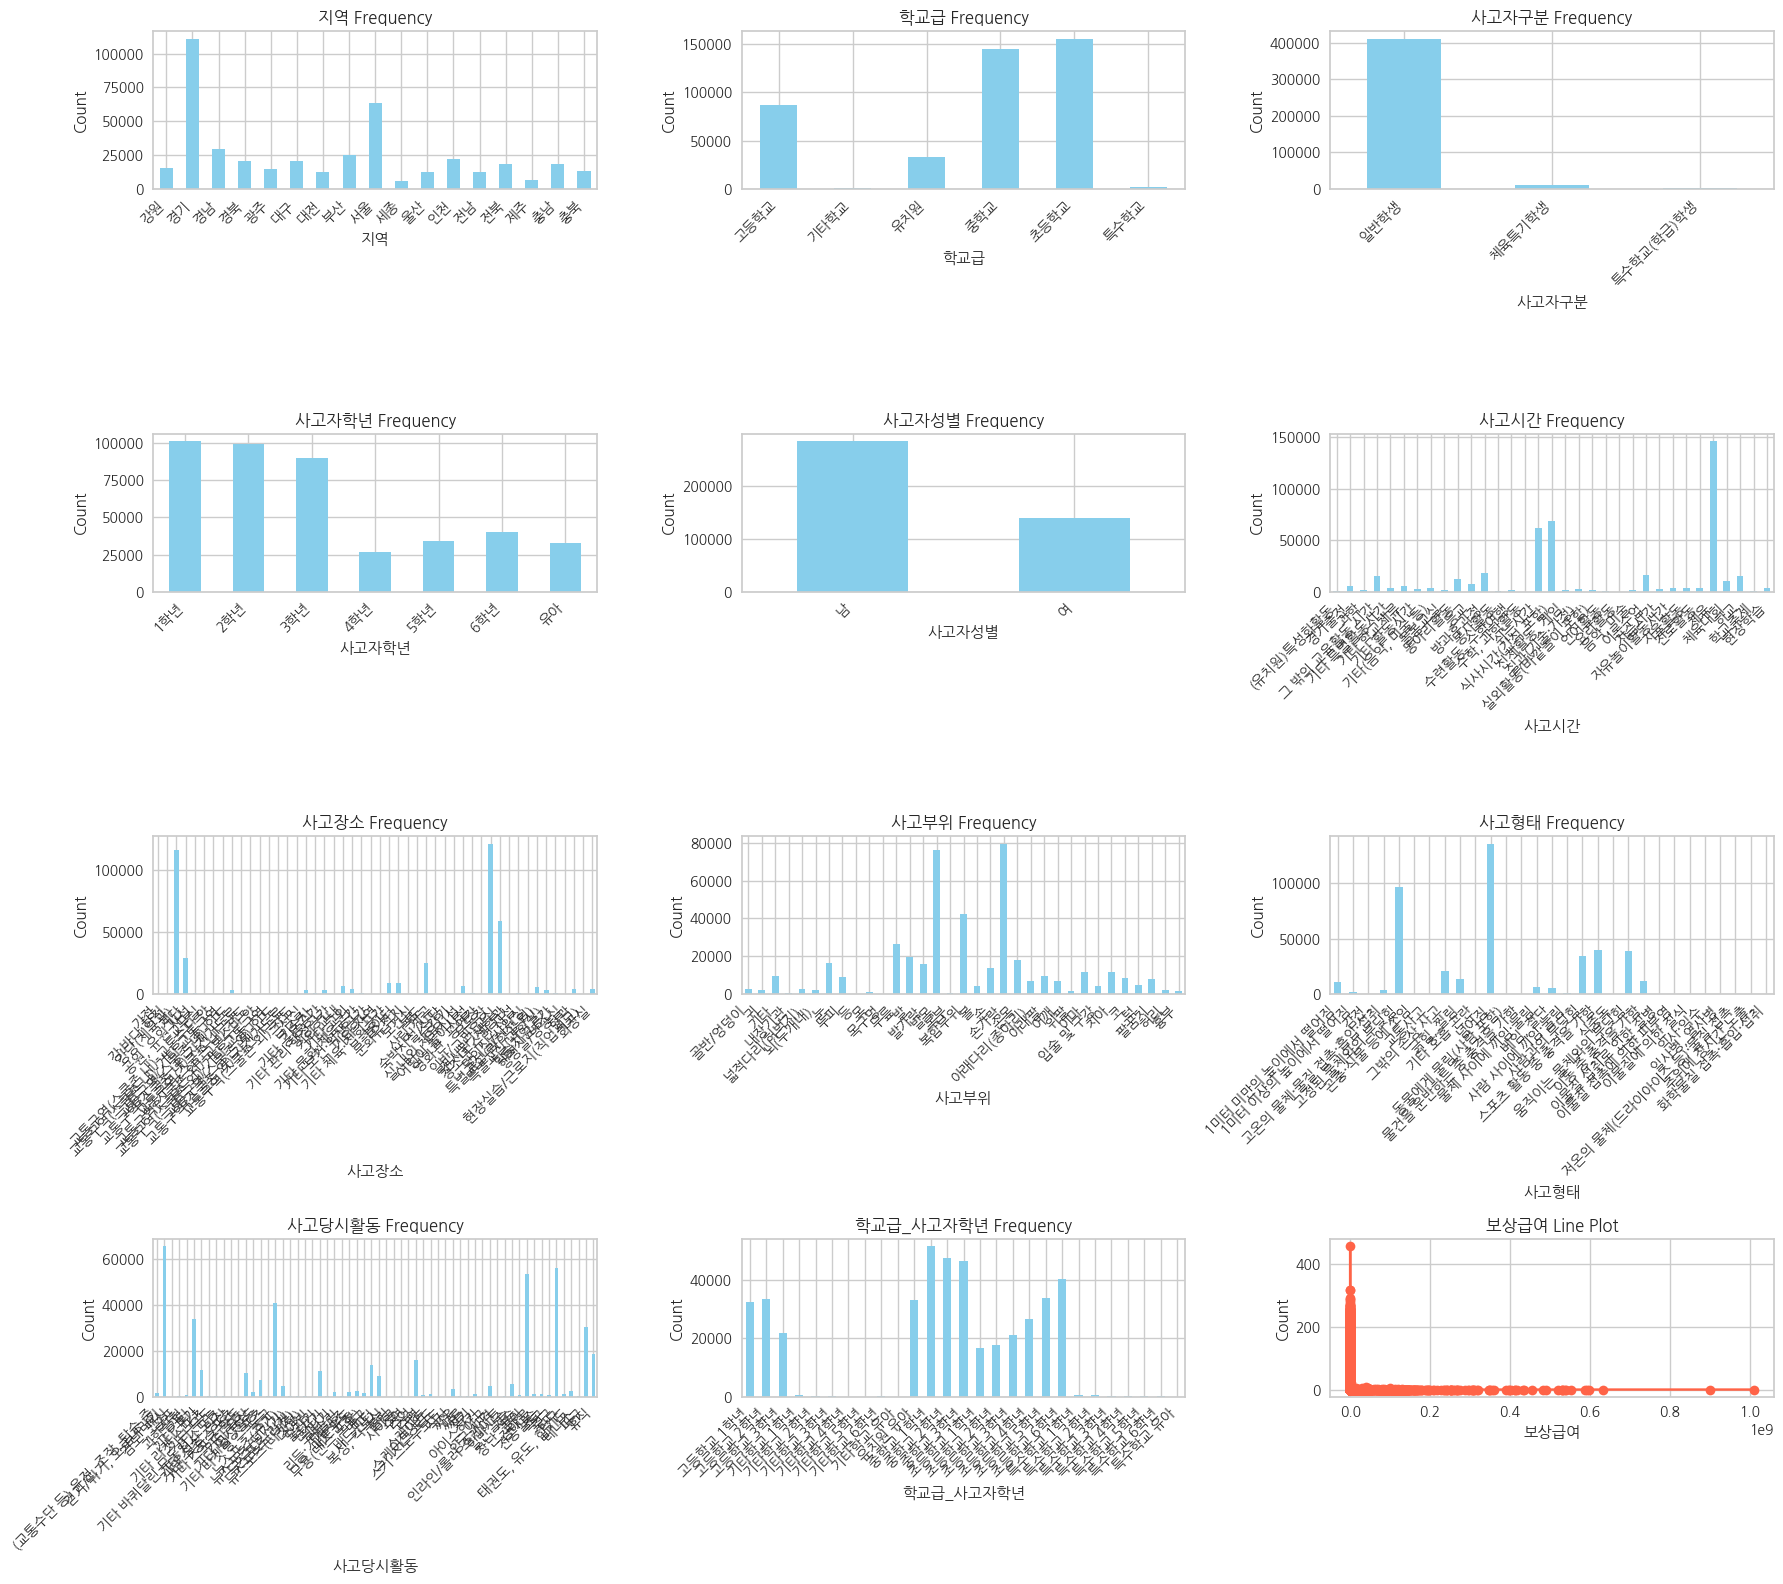

In [88]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.__init__()

fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

data = merged_df.copy()

# 변수 구분
categorical_vars = [col for col in data.columns if data[col].dtype == 'object' or data[col].dtype.name == 'category']
numeric_vars = [col for col in data.columns if pd.api.types.is_integer_dtype(data[col])]

# 시각화할 전체 변수 리스트
all_vars = categorical_vars + numeric_vars

# 레이아웃 설정
n = len(all_vars)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

plt.figure(figsize=(6 * n_cols, 4 * n_rows))

for idx, var in enumerate(all_vars, 1):
    plt.subplot(n_rows, n_cols, idx)

    if var in categorical_vars:
        # 범주형: 막대그래프
        data[var].value_counts().sort_index().plot(kind='bar', color='skyblue')
        plt.title(f'{var} Frequency')
        plt.xlabel(var)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        
    elif var in numeric_vars:
        # 정수형: 선그래프
        counts = data[var].value_counts().sort_index()
        plt.plot(counts.index, counts.values, marker='o', linestyle='-', color='tomato')
        plt.title(f'{var} Line Plot')
        plt.xlabel(var)
        plt.ylabel('Count')

plt.tight_layout()
plt.show()


- 시각화로 본 일반적 빈도 확인
    - 일반적 사실
        - 서울 경기권이 사고 빈도 높음: 서울 경기권의 전체 인구수가 많기 때문에
        - 체육특기학생과 특수학교학생에 비해 일반학생이 사고 빈도 높음: 일반학생인 경우가 실제로 더 많기 때문에
        - 1, 2, 3학년이 4, 5, 6학년보다 사고 빈도 높음: 중/고등학교는 1,2,3학년 까지 밖에 없기 때문에


> 나머지 범주형 데이터의 경우 고유 항목이 많기 때문에 개별 시각화로 확인

In [21]:
def plotting_bar(data, var):
    # 값 개수 및 정렬
    counts = data[var].value_counts().sort_values(ascending=True)  # 오름차순 정렬로 보기 좋게
    total = counts.sum()
    
    # 그래프 크기 크게
    plt.figure(figsize=(12, 8))
    
    # 수평 막대 그래프
    bars = plt.barh(counts.index.astype(str), counts.values, color='skyblue')
    
    # 타이틀 및 축 레이블
    plt.title(f'{var} 빈도 및 비율', fontsize=20)
    plt.xlabel('Count', fontsize=16)
    plt.ylabel(var, fontsize=16)
    
    # 막대 끝에 빈도수 표시
    for bar, count in zip(bars, counts.values):
        width = bar.get_width()
        pct = count / total * 100
        plt.text(width + max(counts.values)*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{int(count)} ({pct:.1f}%)',
                 va='center', fontsize=14)

    plt.tight_layout()
    plt.show()

def plotting_hist(data, var, lim1 = None, lim2 = None, bins=50,):
    
    # 그래프 크기 크게
    plt.figure(figsize=(12, 8))
    
    # 히스토그램
    counts, bin_edges, patches = plt.hist(data[var], bins=bins, color='skyblue', edgecolor='black')

    # 타이틀 및 축 레이블
    plt.title(f'{var} 히스토그램', fontsize=20)
    plt.xlabel(var, fontsize=16)
    plt.ylabel('Count', fontsize=16)
    plt.ylim([lim1, lim2])

    plt.tight_layout()
    plt.show()


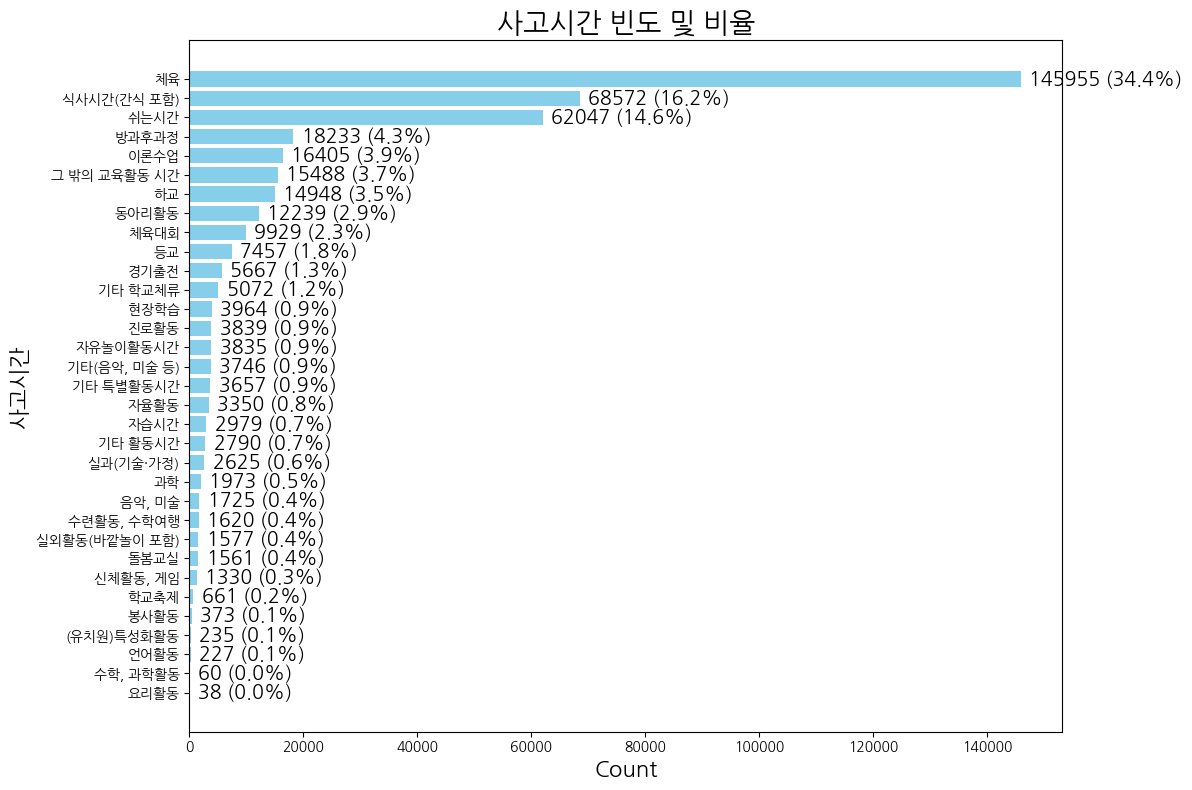

In [22]:
plotting_bar(data, '사고시간')

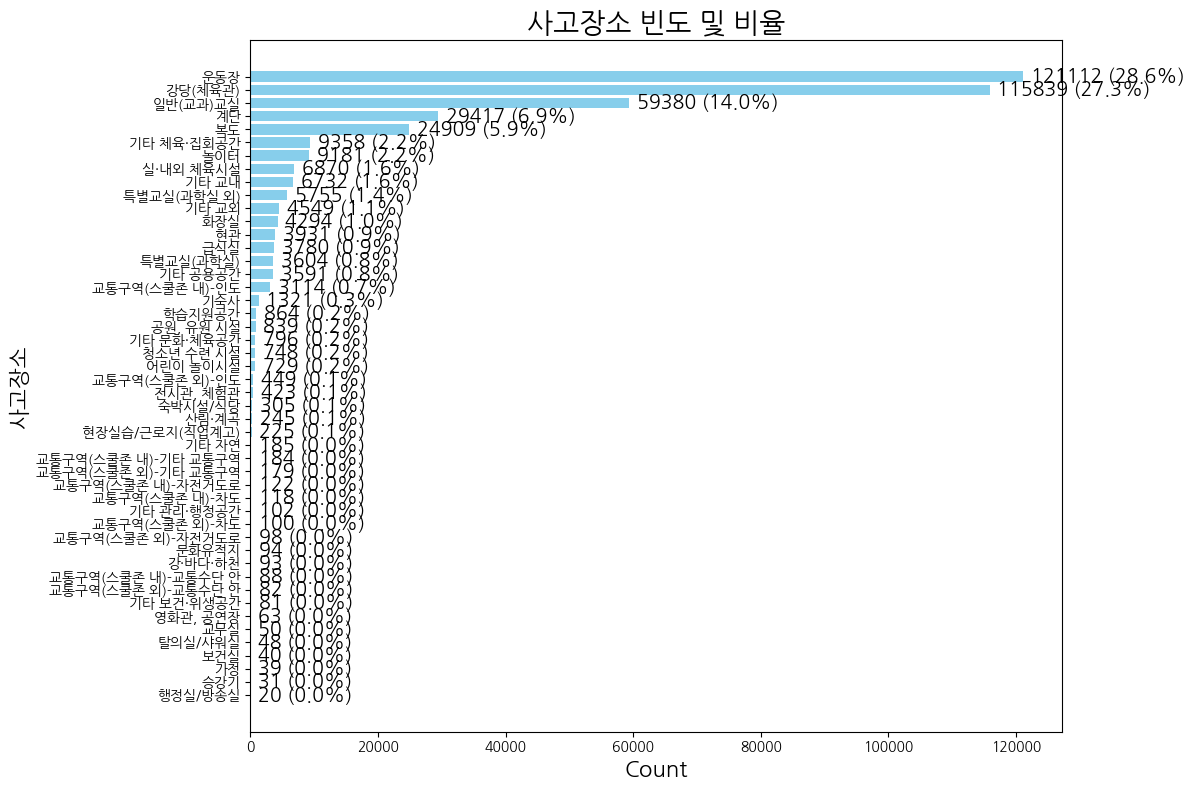

In [23]:
plotting_bar(data, '사고장소')

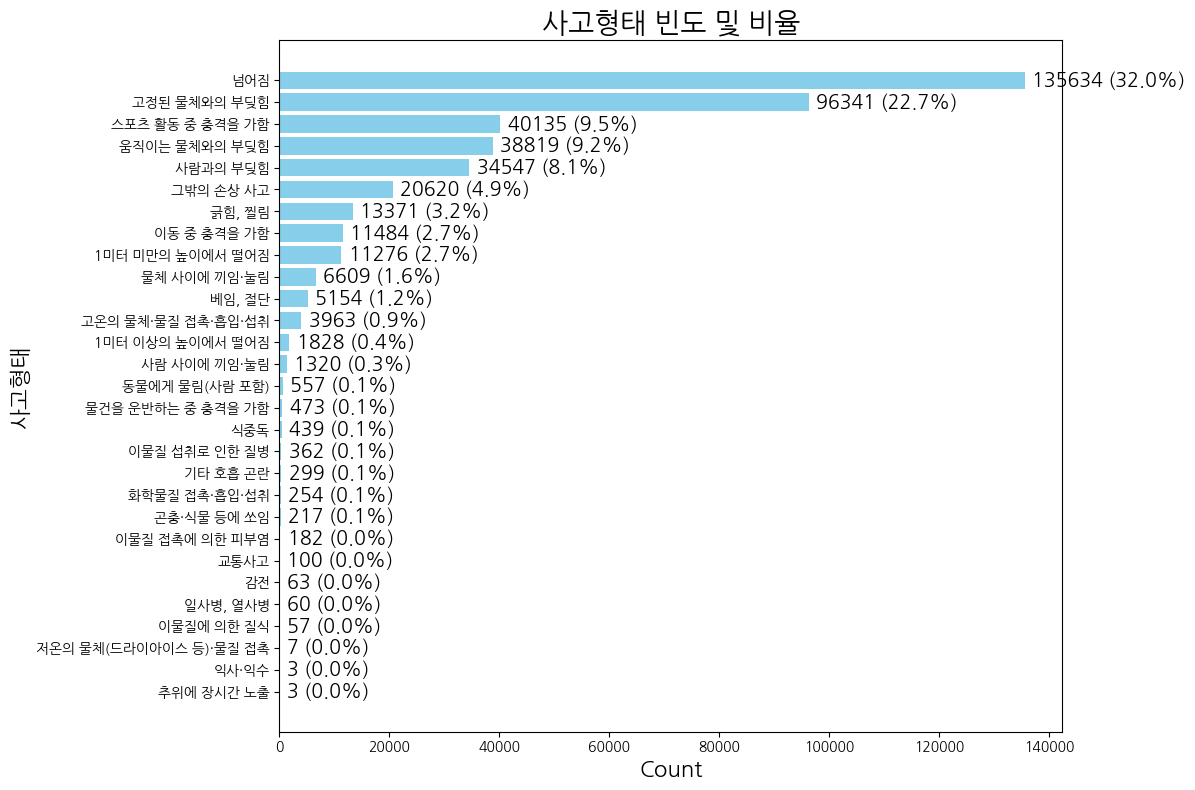

In [24]:
plotting_bar(data, '사고형태')

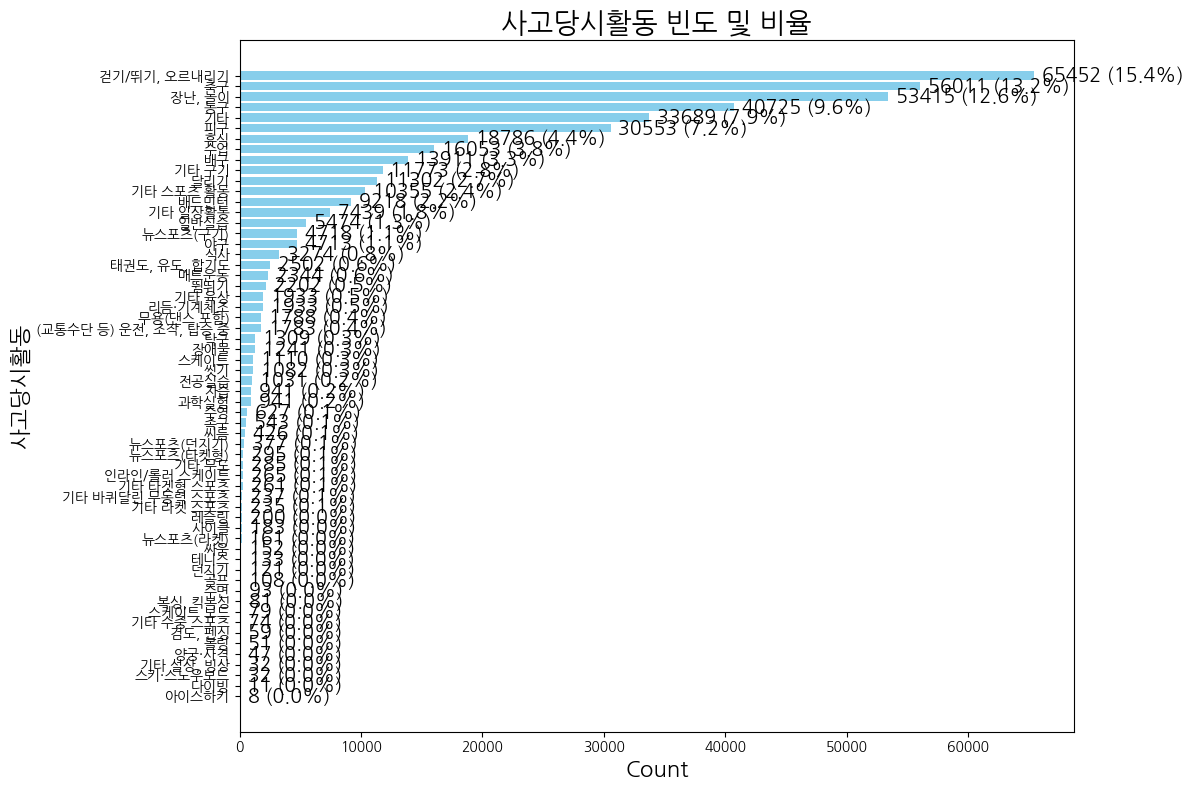

In [25]:
plotting_bar(data, '사고당시활동')

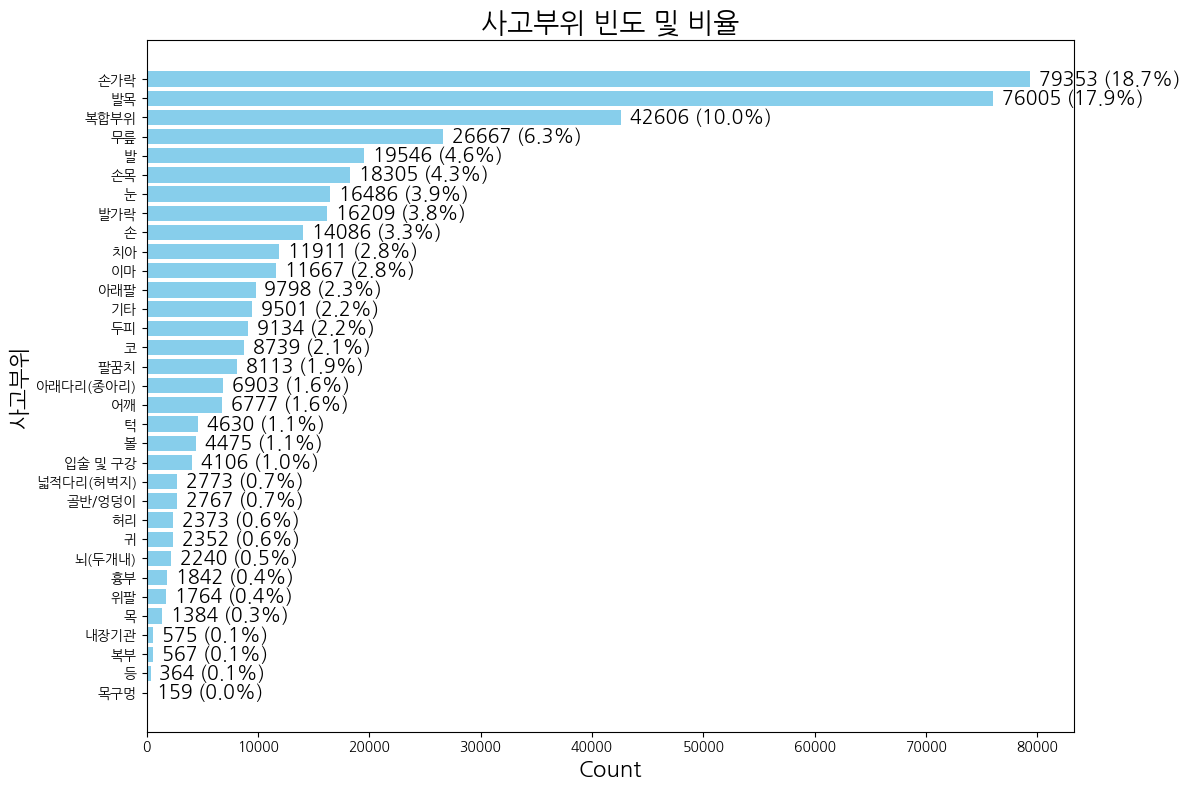

In [26]:
plotting_bar(data, '사고부위')

- **범주별 정리**
    - **사고시간**: 활동량이 많은 체육시간이 1/3차지. 2순위와 3순위인 식사시간, 쉬는시간을 포함하면 총 65.2%를 차지
    - **사고장소**: 체육시간에 쓰이는 강당과 운동장, 쉬는시간/식사시간에 쓰이는 교실, 계단 및 복도가 총 82.7% 차지
    - **사고형태**: 대상이 무엇이든 넘어지고 부딪히는 형태가 72% 차지
    - **사고당시활동**: 5% 이상의 상위 항목에는 걷기/뛰기/오르내리기/장난과 같은 일상 속 활동과 축구/농구/피구와 같은 구기 종목 활동들이 분포
    - **사고부위**: 비교적 많은 비율을 차지하는 것은 손가락 18.7%, 발목 17.9%

> 일반적인 EDA로는 추가적인 분석이라고 보기 어려움. **그저 단순한 빈도이기 때문에 차별점이 없다**
> 
> 추가적인 분석으로 상관분석을 진행하여 변수간의 관계를 알아보기로 함

### 상관분석

범주형 변수와 연속형 변수(보상급여)가 있기 때문에 이들 모두의 상관을 구할 수 있는 phik 라이브러리를 사용하여 분석을 진행

interval columns not set, guessing: ['보상급여']


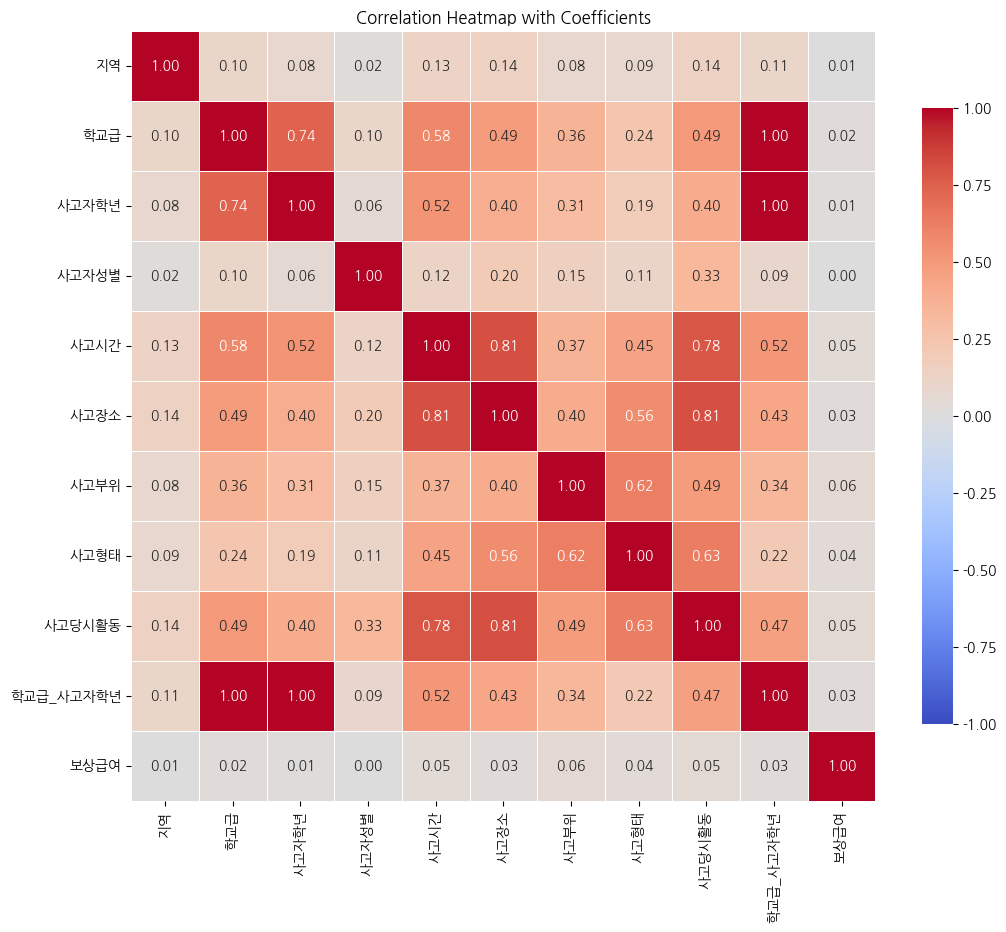

In [28]:
import phik
from phik import resources, report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#일반학생이 대부분이 '사고자 구분' 항목은 너무 편향되어 있어 상관을 보기 어렵다고 판단. 제거

data_for_cor = data.drop(columns=['사고자구분'], inplace = False)
cor_matrix = data_for_cor.phik_matrix()

plt.figure(figsize=(12, 10))
sns.heatmap(
    cor_matrix,
    annot=True,            # 상관계수 표시
    fmt=".2f",             # 소수점 2자리
    cmap="coolwarm",       # 색상맵
    vmin=-1, vmax=1,       # 상관계수 범위
    linewidths=0.5,        # 셀 간격
    cbar_kws={"shrink": .8} # colorbar 크기 조절
)
plt.title("Correlation Heatmap with Coefficients")
plt.show()

- **사고자 학년, 학교급, 학교급_사고자학년 상관**: '학교급_사고자학년' 변수 자체가 사고자학년과 학교급의 파생변수이기 때문에 당연히 상관이 존재.

- **사고시간, 사고장소, 사고형태, 사고당시활동, 사고부위**: 학교라는 공간 특성상 정해진 시간에 정해진 장소에 있을 가능성이 높고 장소에 따라 당시에 무엇을 했는지, 어떤 사고인지, 그래서 어딜 다쳤는지 유추할 수 있기 때문에 상관이 높을 것이라는게 일반적 사실 (ex. 농구중 다침 -> 운동장일 가능성이 매우큼 -> 장소와 활동의 상관이 높을 가능성이 큼)

> 궁금한 것은 학교급/사고자학년/학교급_사고자학년인 **수준 변수**가 사고시간/장소/부위/당시활동/형태인 **사건 변수**와 왜 상관이 높을까? 라는 의문
>
> 이를 보기 위해 **수준 변수와 사건 변수간의 분포를 시각화해보았다.**

### 학교급, 학년 분포 분석

In [54]:
def cross_tab_top3(df, col1, col2):
    import pandas as pd
    import matplotlib.pyplot as plt

    cross_tab = pd.crosstab(df[col1], df[col2], normalize='index')

    # 1️⃣ 각 그룹별 top3 범주 구한 뒤 union
    top_categories_set = set()
    for bar_cat in cross_tab.index:
        group_row = cross_tab.loc[bar_cat]
        top3_categories = group_row.sort_values(ascending=False).head(3).index.tolist()
        top_categories_set.update(top3_categories)

    top_categories_list = list(top_categories_set)

    # 2️⃣ '학교급'일 때만 순서 적용
    if col1 == '학교급':
        school_order = ['초등학교', '중학교', '고등학교', '특수학교', '유치원', '기타학교']
        available_labels = [label for label in school_order if label in cross_tab.index]
        cross_tab = cross_tab.loc[available_labels]

    # 3️⃣ Stacked Bar Chart
    ax = cross_tab.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')

    # 4️⃣ Legend를 top_categories_list만 표시
    handles, labels = ax.get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    filtered_handles = [label_to_handle[label] for label in labels if label in top_categories_list]
    filtered_labels = [label for label in labels if label in top_categories_list]

    ax.legend(filtered_handles, filtered_labels, title=col2, bbox_to_anchor=(1.05, 1))

    # 5️⃣ Annotate는 각 그룹별 top3만 표시
    for idx, bar_cat in enumerate(cross_tab.index):
        group_row = cross_tab.loc[bar_cat]
        top3_categories = group_row.sort_values(ascending=False).head(3).index.tolist()

        y_offset = 0
        for cat in cross_tab.columns:
            val = group_row[cat]
            if val > 0.01 and cat in top3_categories:
                ax.text(idx,
                        y_offset + val / 2,
                        f"{val*100:.1f}%",
                        ha='center', va='center',
                        fontsize=9, color='black')
            y_offset += val

    plt.ylabel('Proportion')
    plt.title(f'Stacked Bar Chart: Group-wise Top 3 Annot, Filtered Legend ({col1} vs {col2})')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

cat_cols = ['사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동']

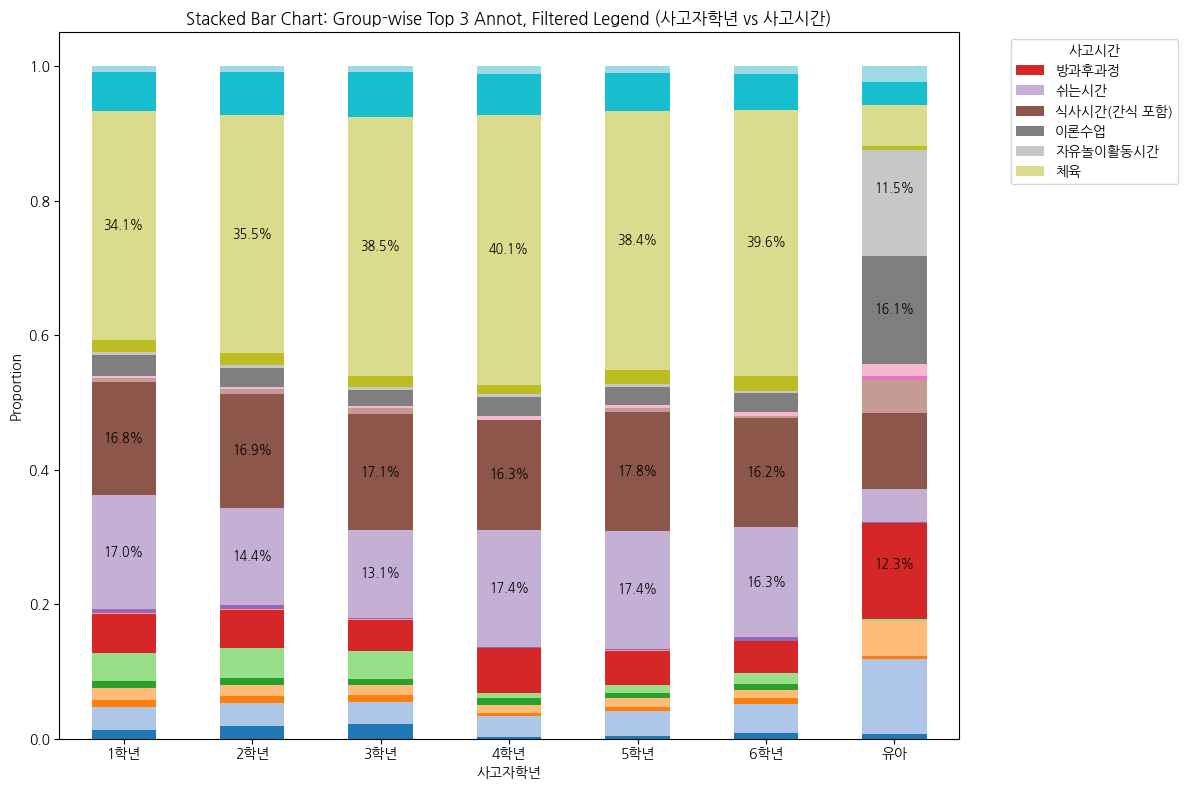

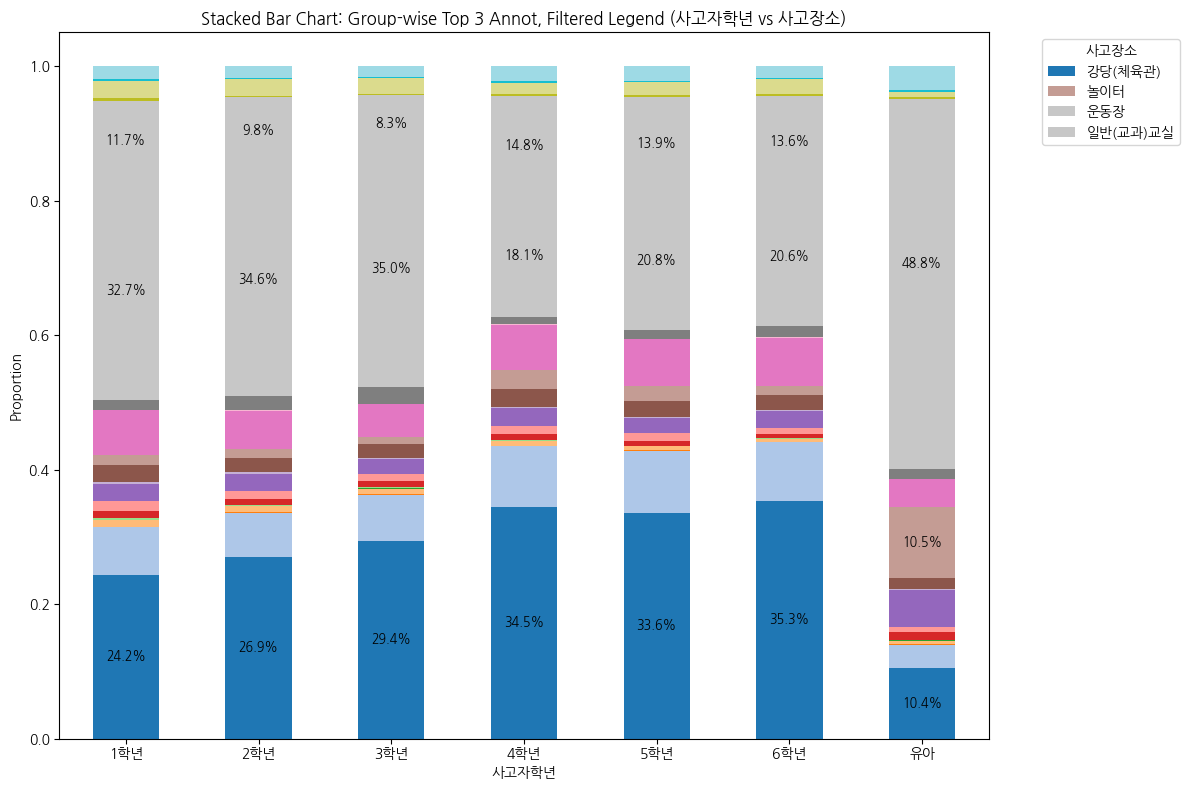

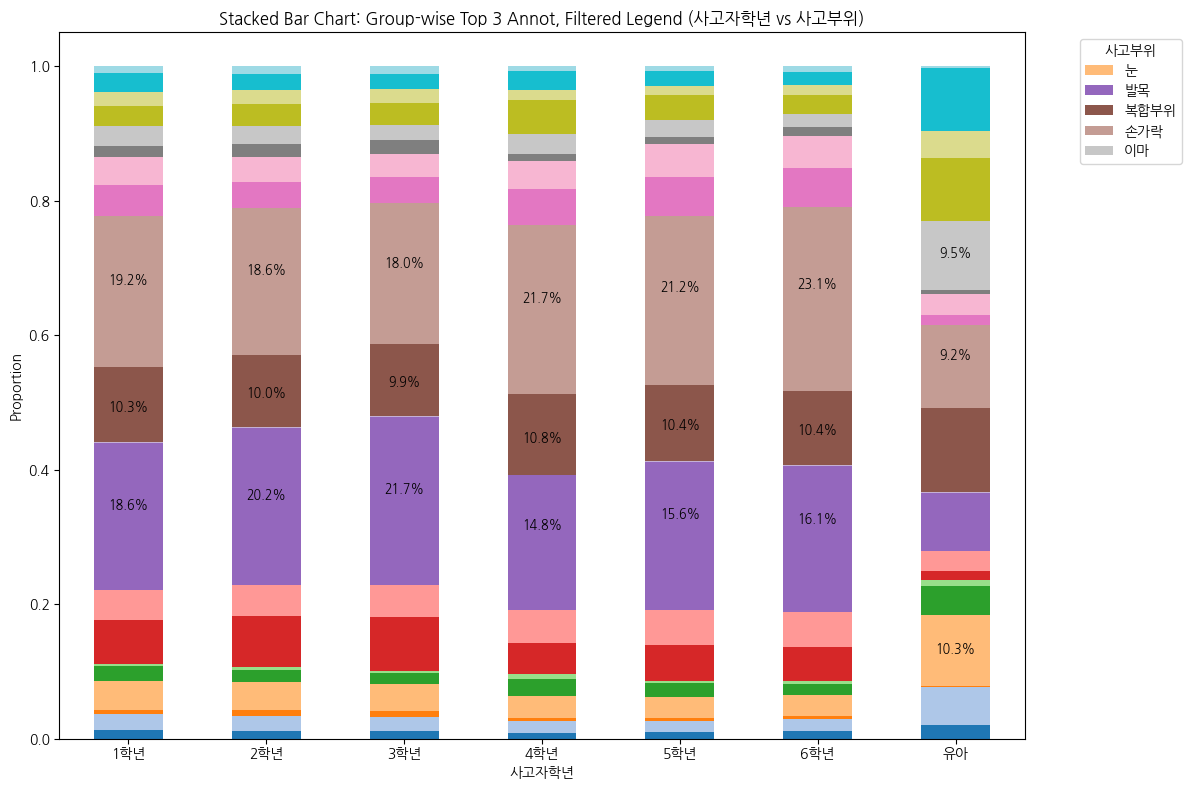

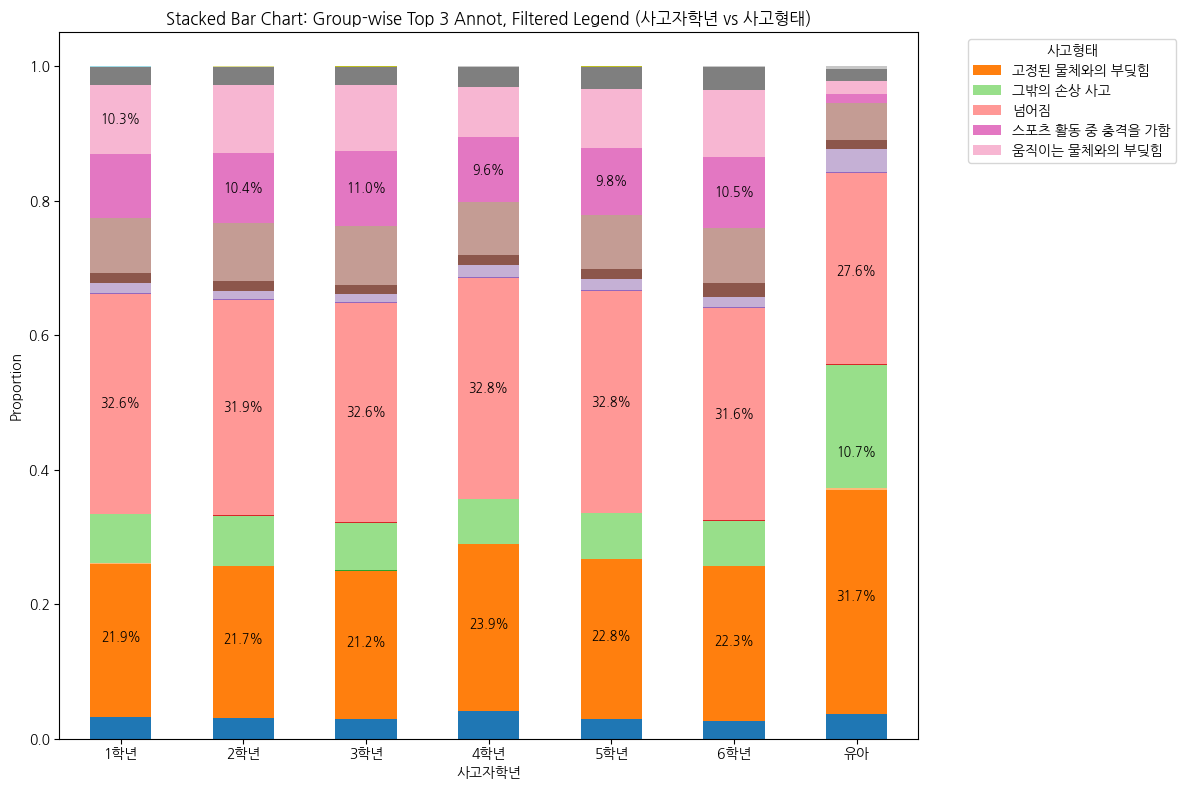

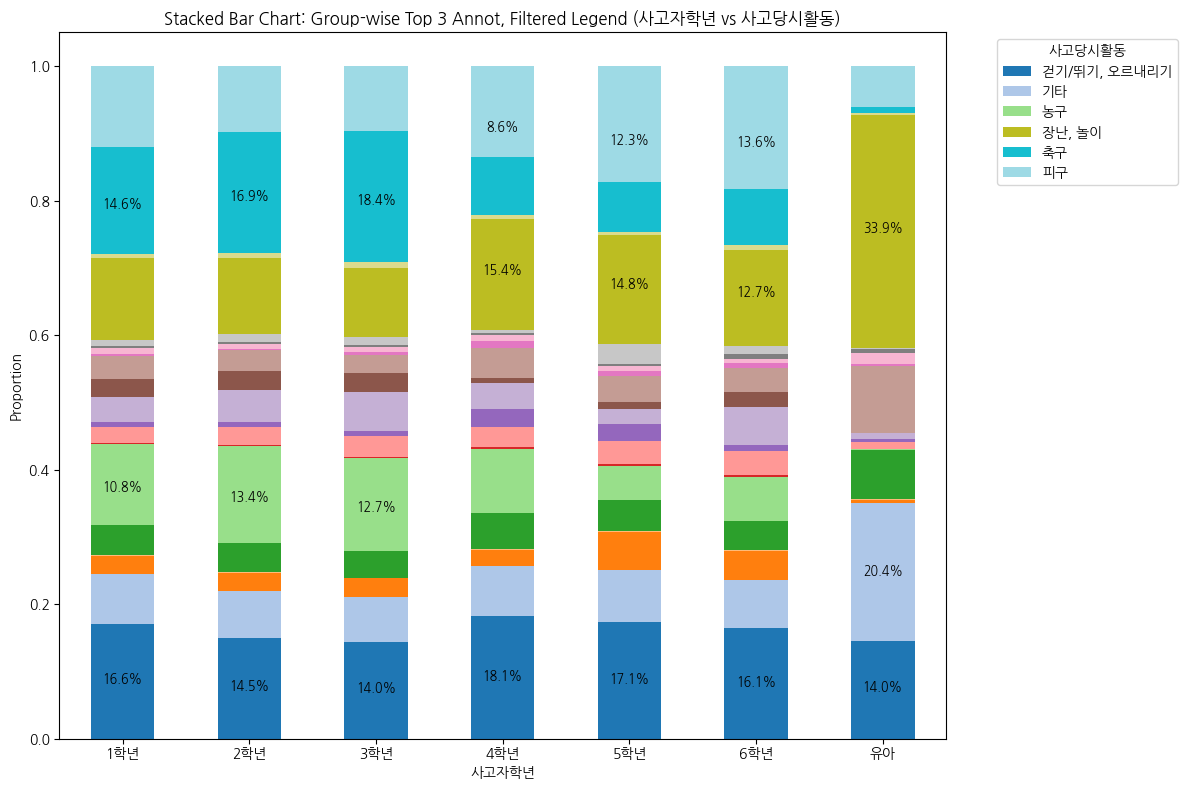

In [55]:
for i in cat_cols:
    cross_tab_top3(data, '사고자학년', i)

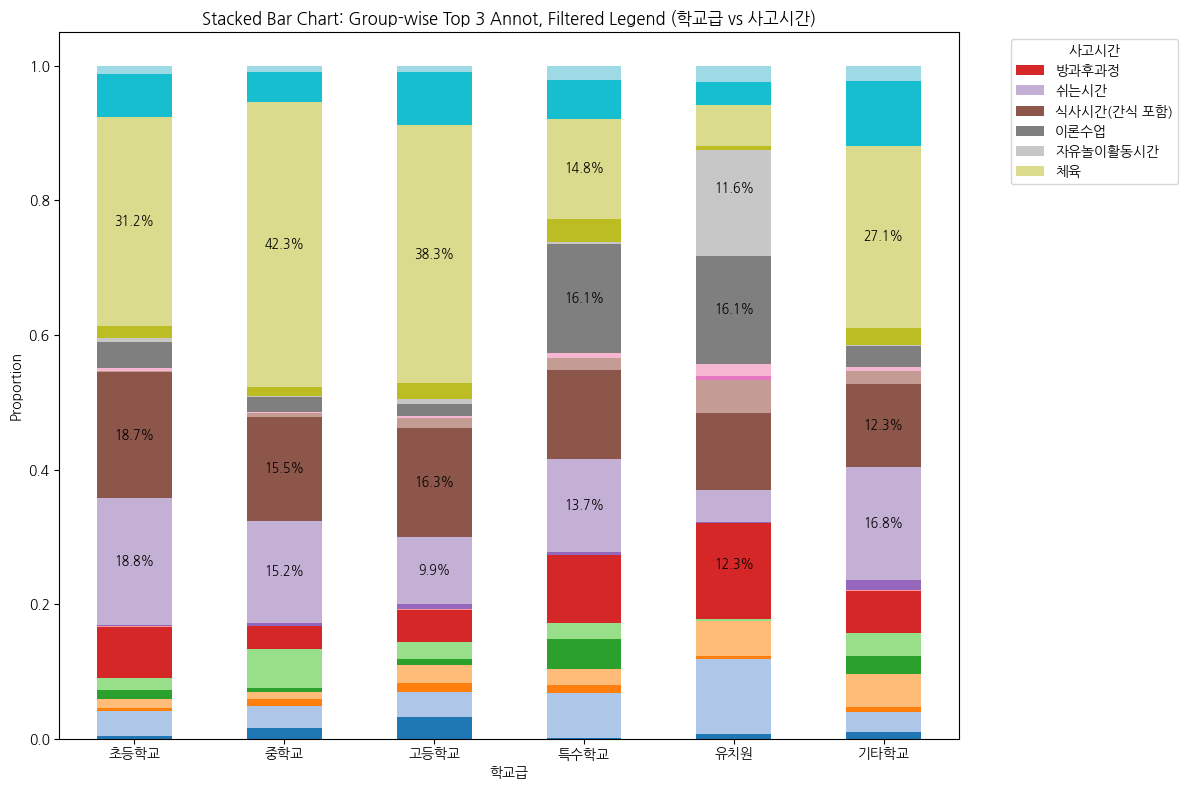

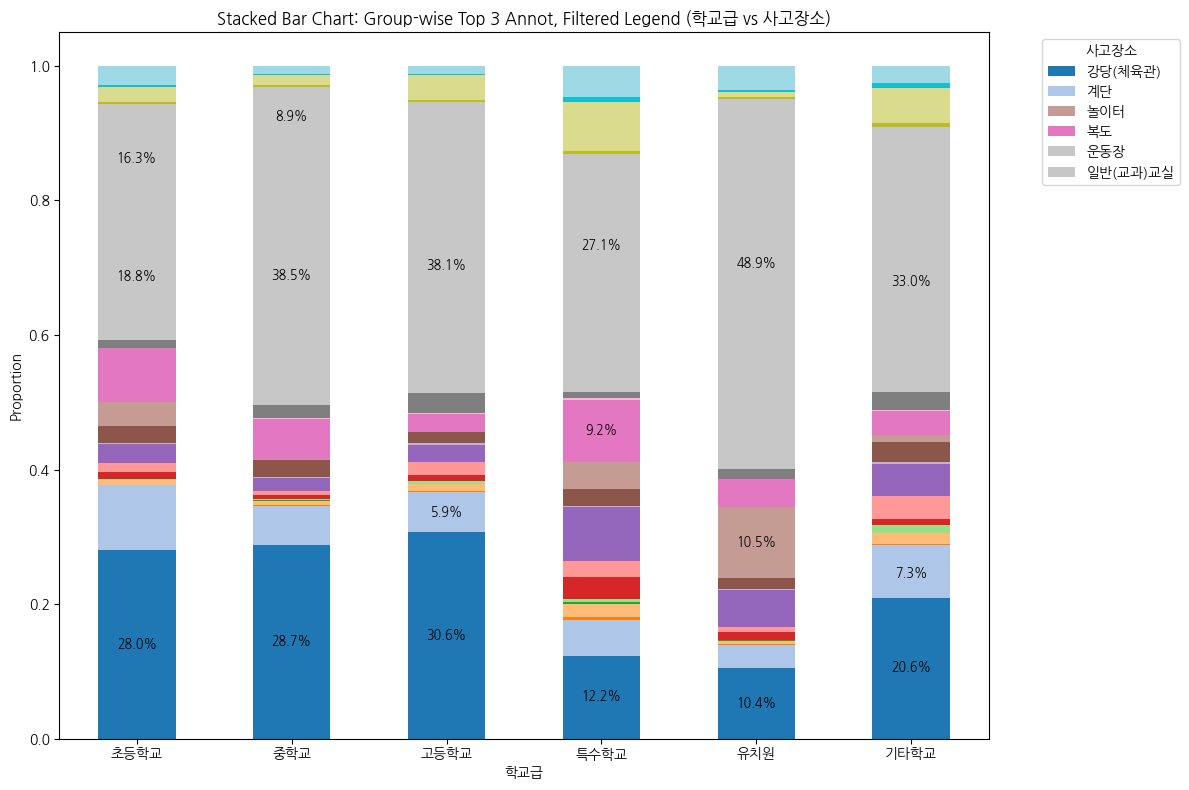

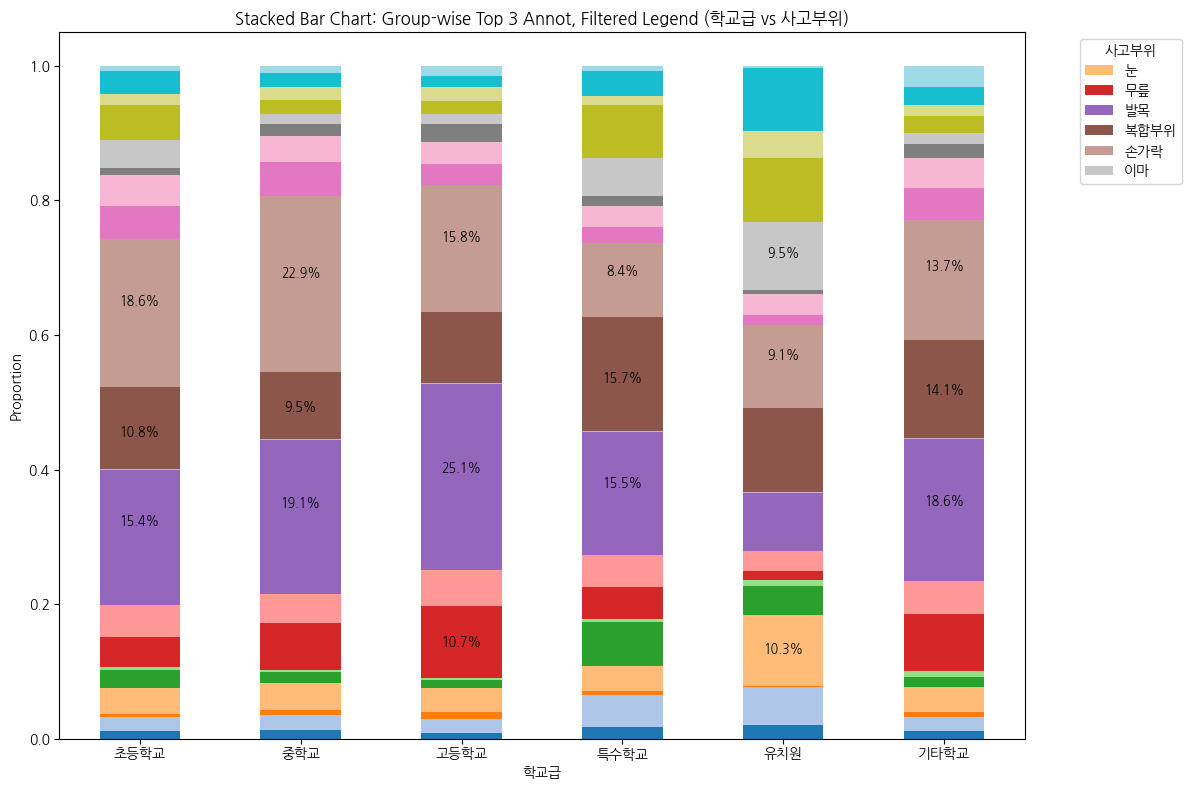

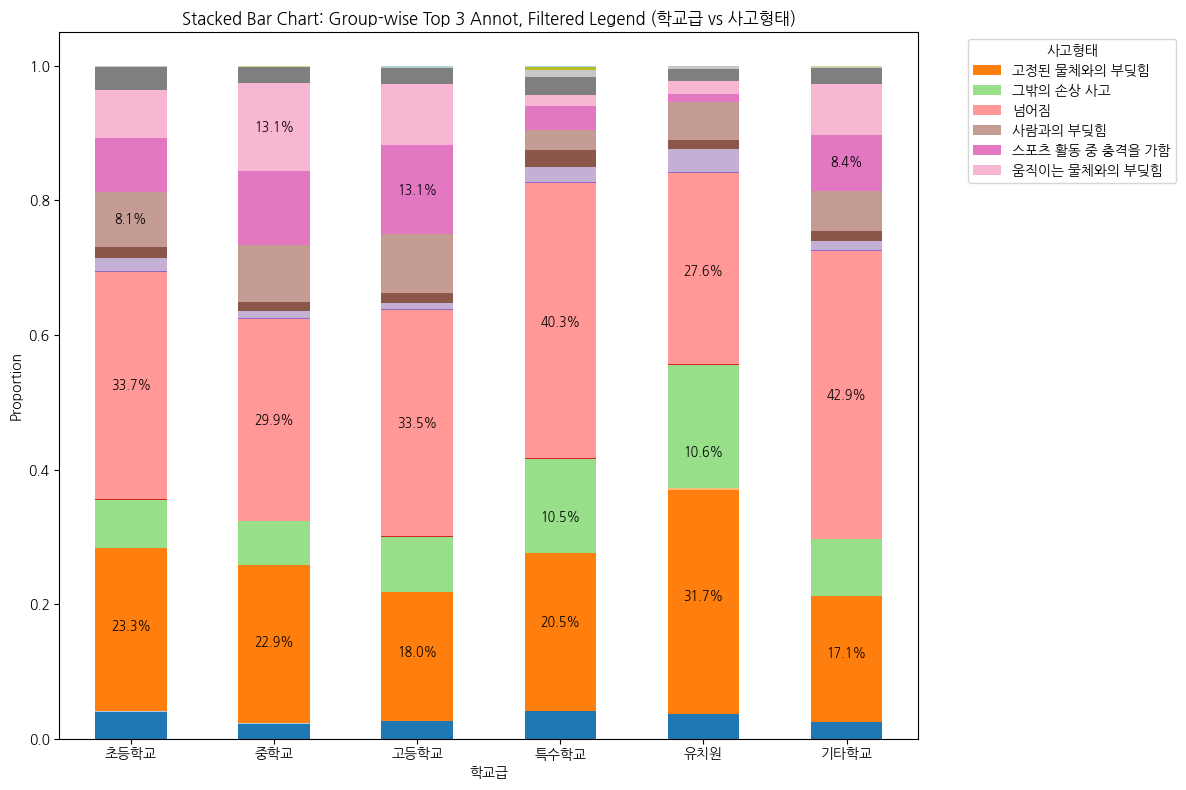

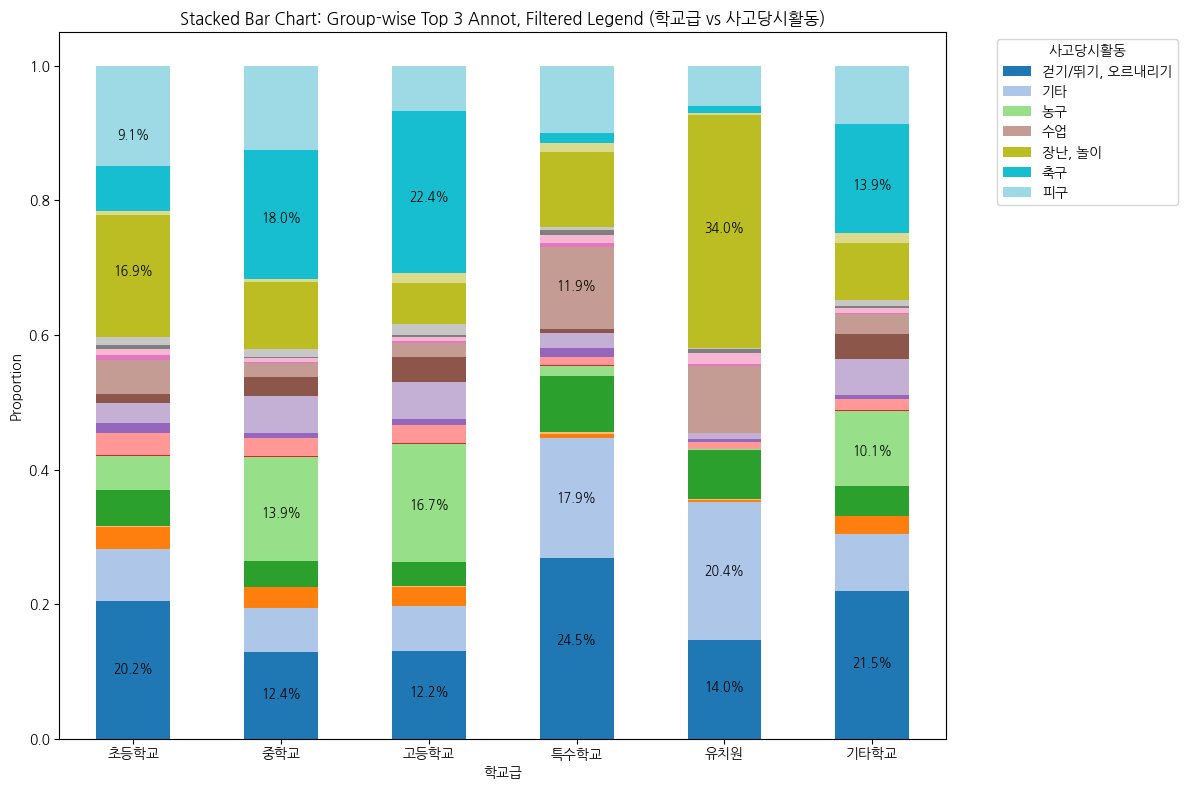

In [35]:
for i in cat_cols:
    cross_tab_top3(data, '학교급', i)

- **사고자학년**
    - '1 ~ 6학년'까지의 비율 분포는 모든 사건 변수에서 서로 비슷한 양상을 보인다.
    - 반면 **'유아'는 모든 사건 변수에서 1 ~ 6학년과는 다른 양상을 보인다.**

          - ex) 사고시간: '1 ~ 6학년'은 체육시간이, '유아'는 이론수업/자유놀이활동시간이 가장 큰 비율
          - ex) 사고당시활동: '1 ~ 6학년'은 축구/피구 활동이, '유아'는 장난/놀이 활동이 가장 큰 비율


- **학교급** (기타 학교는 기술학교, 방통중고등학교, 외국인 학교등 범주가 너무 많아 제외)
    - '초/중/고등학교'까지의 비율 분포는 대부분의 사건 변수에서(사고당시활동은 약간 다름) 비슷한 양상을 보인다.
    - 사고자학년의 경우와 유사하게 **'유치원'은 초/중/고등학교와는 모든 사건 변수에서 다른 양상을 보인다.**
    - '특수학교'의 비율 분포의 경우 각 사건 변수마다 약간의 차이가 존재하나 유치원에 가까워 보인다.

> 실제 분포가 유사한지 확인하기 위해 유사도 검정을 진행
>
> 각 사건 변수마다 **'특수학교'는 '유치원' 혹은 '초중고' 중 어느 집단에 가까운지 확인하기 위함**

## 유사도 분석

**'특수학교'를 기준으로 '유치원'과 '초중고' 집단간의 유사도를 각각 측정**

- **세 가지의 유사도 분석을 사용하여 편향되지 않은 판단을 하려는 시도를 했음**
- 각 사건 변수 별로 다수결에 의거하여 '특수학교' 집단이 '유치원' 혹은 '초중고'중 어떤 집단과 가까운지를 확인
- 전체 사건 변수에서 나타난 결과의 비율에 따라 결정

1. **코사인 유사도**: 두 벡터 간의 방향의 유사성 측정
- 1에 가까울 수록 유사하다는 의미

2. **유클리디안 거리**: 두 벡터 간의 절댓값 거리 측정
- 0에 가까울 수록 유사하다는 의미

3. **Jensen-Shanon Divergence**: 두 확률 분포 간의 정보 차이 측정
- 0에 가까울 수록 유사다하는 의미

> EDA를 통해 확인하였을 때 각 학교급 별로 아예 존재하지 않는 값이 있다.
>
> 사고가 일어나지 않았다는 의미가 아니라 아예 없는 값(ex. '(유치원)특성화활동'이라는 '사고시간'은 유치원에만 존재)이기 때문에 이러한 값은 제거하여 분석을 진행

In [42]:
from scipy.spatial.distance import cosine, euclidean
from scipy.spatial import distance

# 초중고, 유치원, 특수학교 데이터 분리
초중고 = data[data['학교급'].isin(['초등학교','중학교','고등학교'])]
유치원 = data[data['학교급'] == '유치원']
특수학교 = data[data['학교급'] == '특수학교']

for i in cat_cols:
    # 비율 구하기
    초중고_ratio = 초중고[i].value_counts(normalize=True)
    유치원_ratio = 유치원[i].value_counts(normalize=True)
    특수학교_ratio = 특수학교[i].value_counts(normalize=True)
    
    # 인덱스 맞추기
    idx = 초중고_ratio.index.intersection(유치원_ratio.index).intersection(특수학교_ratio.index)
    초중고_ratio = 초중고_ratio.loc[idx]
    유치원_ratio = 유치원_ratio.loc[idx]
    특수학교_ratio = 특수학교_ratio.loc[idx]
    
    # Cosine Similarity
    sim_유치원 = 1 - cosine(특수학교_ratio, 유치원_ratio)
    sim_초중고 = 1 - cosine(특수학교_ratio, 초중고_ratio)
    sim_result = "유치원" if sim_유치원 > sim_초중고 else "초중고"
    
    # Euclidean Distance
    dist_유치원 = euclidean(특수학교_ratio, 유치원_ratio)
    dist_초중고 = euclidean(특수학교_ratio, 초중고_ratio)
    dist_result = "유치원" if dist_유치원 < dist_초중고 else "초중고"
    
    # JS Divergence
    js_유치원 = distance.jensenshannon(특수학교_ratio, 유치원_ratio)
    js_초중고 = distance.jensenshannon(특수학교_ratio, 초중고_ratio)
    js_result = "유치원" if js_유치원 < js_초중고 else "초중고"

    print(f"✅[{i}]")
    print(f"Cosine Similarity (유치원): {sim_유치원:.4f}")
    print(f"Cosine Similarity (초중고): {sim_초중고:.4f}")
    print(f"→ Cosine 기준, 특수학교는 '{sim_result}'에 더 가까움\n")
    
    print(f"Euclidean Distance (유치원): {dist_유치원:.4f}")
    print(f"Euclidean Distance (초중고): {dist_초중고:.4f}")
    print(f"→ Euclidean 기준, 특수학교는 '{dist_result}'에 더 가까움\n")
    
    print(f"JS Divergence (유치원): {js_유치원:.4f}")
    print(f"JS Divergence (초중고): {js_초중고:.4f}")
    print(f"→ JS Divergence 기준, 특수학교는 '{js_result}'에 더 가까움")
    print("-" * 50 + "\n")

✅[사고시간]
Cosine Similarity (유치원): 0.8196
Cosine Similarity (초중고): 0.7992
→ Cosine 기준, 특수학교는 '유치원'에 더 가까움

Euclidean Distance (유치원): 0.1798
Euclidean Distance (초중고): 0.2690
→ Euclidean 기준, 특수학교는 '유치원'에 더 가까움

JS Divergence (유치원): 0.3031
JS Divergence (초중고): 0.2778
→ JS Divergence 기준, 특수학교는 '초중고'에 더 가까움
--------------------------------------------------

✅[사고장소]
Cosine Similarity (유치원): 0.9165
Cosine Similarity (초중고): 0.6730
→ Cosine 기준, 특수학교는 '유치원'에 더 가까움

Euclidean Distance (유치원): 0.2458
Euclidean Distance (초중고): 0.3333
→ Euclidean 기준, 특수학교는 '유치원'에 더 가까움

JS Divergence (유치원): 0.2583
JS Divergence (초중고): 0.3253
→ JS Divergence 기준, 특수학교는 '유치원'에 더 가까움
--------------------------------------------------

✅[사고부위]
Cosine Similarity (유치원): 0.7833
Cosine Similarity (초중고): 0.8820
→ Cosine 기준, 특수학교는 '초중고'에 더 가까움

Euclidean Distance (유치원): 0.1739
Euclidean Distance (초중고): 0.1501
→ Euclidean 기준, 특수학교는 '초중고'에 더 가까움

JS Divergence (유치원): 0.2590
JS Divergence (초중고): 0.2023
→ JS Divergence 기준, 특수학교는 '초중

- **'특수학교'의 유사도 분석결과 5개의 사건 변수 중 3개의 사건 변수가 '유치원'의 분포와 더 가깝다는 결론**
    - 특히, **'사고장소'** 의 경우 모든 지표가 '특수학교'의 분포는 '유치원'의 분포와 유사하다고 나타남
    - 이에 이어, **'사고당시활동'** 과 **'사고시간'** 의 경우 3개의 지표 중 2개의 지표가 '유치원'의 분포와 유사다하고 나타남

> 지표 뿐 아닌 실제 분포가 유사한지 확인하기 위한 히트맵과 면적 그래프 확인.


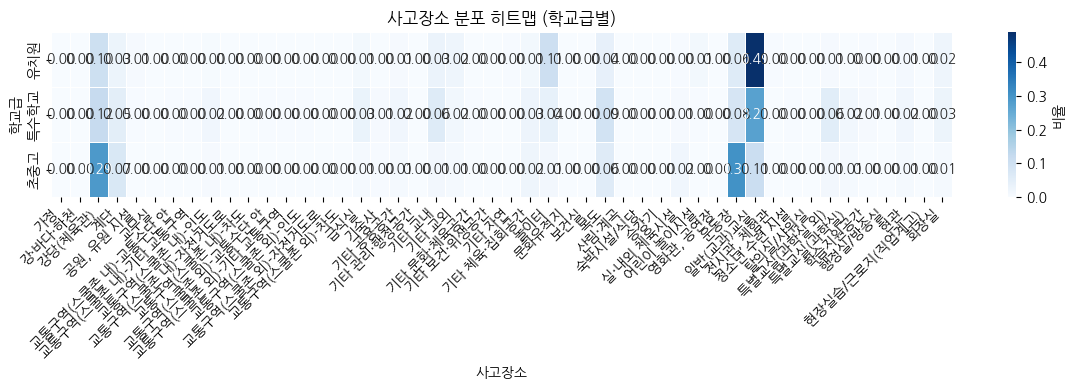

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 사고장소 비율 계산
col = '사고장소'
초중고_ratio = 초중고[col].value_counts(normalize=True).sort_index()
유치원_ratio = 유치원[col].value_counts(normalize=True).sort_index()
특수_ratio = 특수학교[col].value_counts(normalize=True).sort_index()

# 인덱스 통일
idx = 초중고_ratio.index.union(유치원_ratio.index).union(특수_ratio.index)
초중고_ratio = 초중고_ratio.reindex(idx, fill_value=0)
유치원_ratio = 유치원_ratio.reindex(idx, fill_value=0)
특수_ratio = 특수_ratio.reindex(idx, fill_value=0)

# DataFrame 결합
df = pd.DataFrame({
    '유치원': 유치원_ratio,
    '특수학교': 특수_ratio,
    '초중고': 초중고_ratio,
})  # 전치해서 학교급이 행, 사고장소가 열

# 히트맵 시각화
# 사고장소 분포 히트맵 - 가로 방향
plt.figure(figsize=(12, 4))
sns.heatmap(df.T, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5, cbar_kws={'label': '비율'})
plt.title('사고장소 분포 히트맵 (학교급별)')
plt.ylabel('학교급')
plt.xlabel('사고장소')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



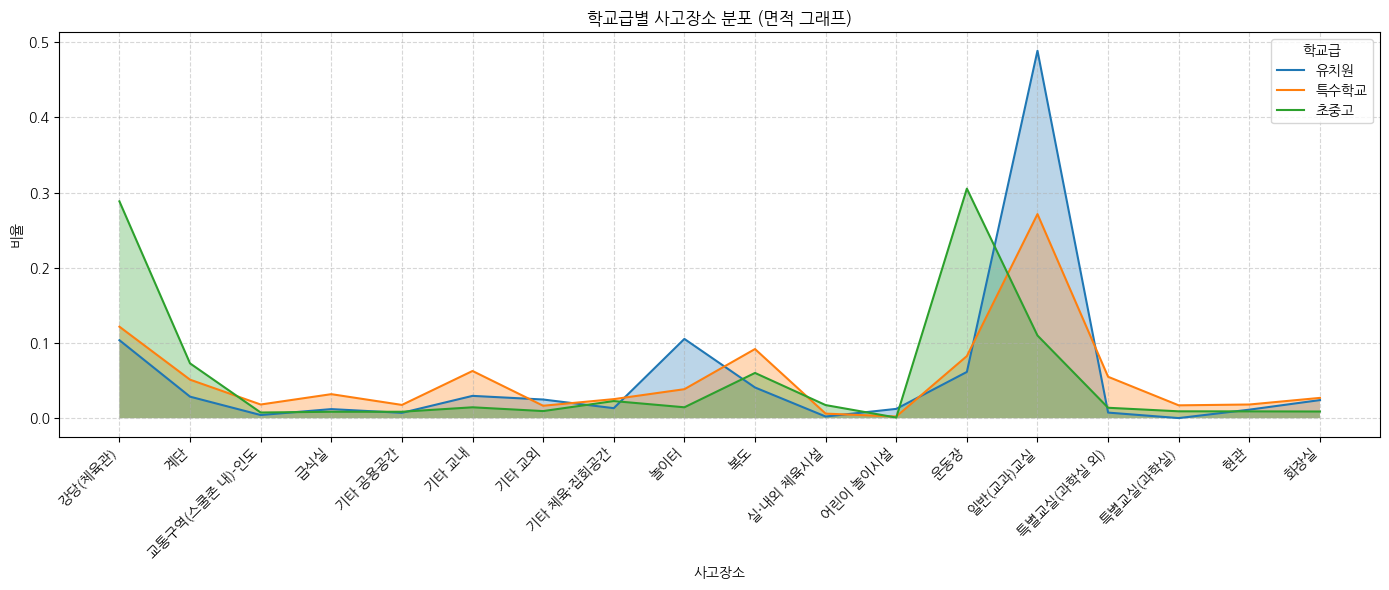

In [64]:
# 비율이 세 학교급에서 모두 0.1 이하인 것은 제거 하여 시각화 편하게 함

import matplotlib.pyplot as plt

# 전치된 선그래프용 데이터프레임: 학교급(행) x 사고장소(열)
df_vertical = df.copy()
df_line = df_vertical

# 세 학교급 모두에서 0인 열(사고장소) 제거
df_line_filtered = df_line.loc[~(df_line <= 0.01).all(axis=1), :]


plt.figure(figsize=(14, 6))

x = df_line_filtered.index

# 각 학교급에 대해 fill_between으로 면적 채우기
for group in df_line_filtered.columns:
    y = df_line_filtered[group]
    plt.plot(x, y, label=group)  # 선 그래프
    plt.fill_between(x, y, alpha=0.3)  # 색 채우기 (alpha=투명도)

plt.title('학교급별 사고장소 분포 (면적 그래프)')
plt.xlabel('사고장소')
plt.ylabel('비율')
plt.xticks(rotation=45, ha='right')
plt.legend(title='학교급')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [61]:
df_line

사고장소,가정,강·바다·하천,강당(체육관),계단,"공원, 유원 시설",교무실,교통구역(스쿨존 내)-교통수단 안,교통구역(스쿨존 내)-기타 교통구역,교통구역(스쿨존 내)-인도,교통구역(스쿨존 내)-자전거도로,...,"전시관, 체험관",청소년 수련 시설,탈의실/샤워실,특별교실(과학실 외),특별교실(과학실),학습지원공간,행정실/방송실,현관,현장실습/근로지(직업계고),화장실
유치원,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
특수학교,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
초중고,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


> **목표**
> 
> 1. 데이터를 기반으로 **'초중고'와 '유아/특수'라는 두 개의 집단으로 나누어 데이터를 보고 어떤 학교급에서 일어난 사고인지 예측하는 모델을 생성**
>
> 2. 모델을 해석하여 **'초중고'와 '유아/특수'의 사건 간 차이에는 어떤 숨겨진 패턴이 있는가를 확인**
>
> 3. 개별 변수들의 중요도가 아닌, 앞서 **'특수학교' 유사성 분석에서 중요한 요인이었던 '사고장소', '사고당시활동', '사고시간' 간의 관계에 대해서도 분석을 진행**
>
> 4. 최종적으로 나온 집단 별 사고 속에 **숨겨진 변수들 간의 관계를 해석하고 이를 예방하기 위한 방안을 모색**


**!! 솜이에게 !!**
마지막에 사고장소, 사고당시활동, 사고시간을 넣은 이유는 그 빨강 파랑 그래프를 우리가 2번 4번을 보았는데 그게 딱 저 사고장소, 사고당시활동, 사고시간이다.

기획서에는 4번인 사고장소와 시간은 실제로 보니 상관이 없었었고, 2번은 있었다. 그래서 2번을 중심으로 해석하고 예방 방안을 모색했다 라는 식으로 쓰기 위함

## 모델 학습

'유아/특수' 집단과 '초중고' 집단의 사고를 예측하는 모델(알고리즘)을 생성하고 앞서 유사도 검정에서 살펴보았던 '사고장소'가 예측에 어떤 영향을 미치는지 Shap value를 통해 확인. 또한, '사고장소'와 두 번째로 중요했던 요인인 '사고당시활동', '사고시간'과의 관계를 확인

Shap value: AI 모델이 어떤 결정을 내릴 때, 모든 특성을 하나씩 넣었다 뺐다 해보면서, 그 특성이 예측 결과에 얼만큼 영향을 주는지 공정하게 계산하는 변수 중요도 계산 방법. 마치 팀플에서 '이 사람이 빠졌을 때 결과가 어떻게 바뀌는지' 실험하는 방법과 같다.

### 예측 방법 및 변수 중요도 해석

- '유아/특수', '초중고' 두 집단을 각각 종속변수로 삼아 1과 0으로 인코딩
- 보상급여의 경우 0원에서 1억원까지 분포. 그 중에서도 대부분의 변수가 2천만원을 넘지 않기 때문에(99% 이상이 분포하고 있다.) 모델 예측에 어려움이 될 수 있다.
  - log 변환을 통해 편포를 줄임
 
- 남은 변수들인 '사고자성별', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동'을 예측 변수로 넣어 AI 모델을 설계
- pycaret의 AutoML을 사용(여러 모델을 자동으로 설계해 예측해주고 순위를 매겨주는 라이브러리)하여 가장 좋았던 모델인 XGBoost를 사용

XGboost: 여러개의 의사 결정 트리를 종속적으로 생성하여 점차 정확도를 향상시켜가는 AI 학습 기법

- 마지막으로 Shap value를 계산하고 시각화하여 해석하고 예방안을 제시

In [69]:
# 1) target 생성
data['target'] = data['학교급'].map(
    lambda x: 0 if x in ['초등학교', '중학교', '고등학교'] else (1 if x in ['특수학교', '유치원'] else np.nan)
)

# 2) 기타학교 제거
data = data.dropna(subset=['target']).copy()
data['target'] = data['target'].astype(int)

print(data['target'].value_counts())

target
0    387972
1     34812
Name: count, dtype: int64


In [70]:
# 3) 로그 변환
data['log_보상급여'] = np.log1p(data['보상급여'])

# 확인
print(data[['보상급여', 'log_보상급여']].describe())

               보상급여  log_보상급여
count       422,784   422,784
mean        467,617        12
std       5,820,941         1
min               0         0
25%          58,400        11
50%         114,485        12
75%         277,800        13
max   1,010,000,000        21


In [72]:
pre = data[['사고자성별', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', 'log_보상급여', 'target']]
pre

,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,log_보상급여,target
0,남,쉬는시간,강당(체육관),골반/엉덩이,그밖의 손상 사고,기타,10,0
1,여,체육,운동장,두피,그밖의 손상 사고,기타 스포츠 활동,11,0
2,남,그 밖의 교육활동 시간,기타 교외,기타,그밖의 손상 사고,기타,17,0
3,남,쉬는시간,일반(교과)교실,어깨,그밖의 손상 사고,기타,15,0
4,남,식사시간(간식 포함),기타 교외,치아,고정된 물체와의 부딪힘,기타,14,0
...,...,...,...,...,...,...,...,...
425207,여,체육,특별교실(과학실 외),손가락,움직이는 물체와의 부딪힘,피구,11,0
425208,여,쉬는시간,일반(교과)교실,무릎,넘어짐,휴식,14,1
425209,여,체육,강당(체육관),손가락,고정된 물체와의 부딪힘,피구,11,0
425210,남,체육,강당(체육관),복합부위,사람과의 부딪힘,기타 구기,13,0


In [73]:
#from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder

# 1️⃣ Label Encoding
cat_cols = ['사고자성별', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    pre[col] = le.fit_transform(pre[col].astype(str))
    le_dict[col] = le  # 역변환용 저장

# 2️⃣ Feature, Target 구성
X = pre[['사고자성별', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', 'log_보상급여']]
y = pre['target']

# 3️⃣ categorical feature index 설정 (X의 컬럼 순서 기준)
cat_features = [0, 1, 2, 3, 4, 5]  # 앞의 6개 컬럼이 범주형

# 4️⃣ SMOTENC 적용
#smote_nc = SMOTENC(
#    categorical_features=cat_features,
#    sampling_strategy=0.5,
#    random_state=42
#)
# X_resampled, y_resampled = smote_nc.fit_resample(X, y)

X_resampled, y_resampled = X, y

# 5️⃣ 결과 확인
print(y_resampled.value_counts())


target
0    387972
1     34812
Name: count, dtype: int64


/tmp/ipykernel_730550/2601648399.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre[col] = le.fit_transform(pre[col].astype(str))
/tmp/ipykernel_730550/2601648399.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre[col] = le.fit_transform(pre[col].astype(str))
/tmp/ipykernel_730550/2601648399.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

In [74]:
from pycaret.classification import *

clf = setup(
    data= X_resampled,
    target = y_resampled,
    session_id = 42,
    fold = 5,
    use_gpu = True,
    categorical_features = ['사고자성별', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동'],
    numeric_features = ['log_보상급여'],
)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4090, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Original data shape,"(422784, 8)"
4,Transformed data shape,"(422784, 8)"
5,Transformed train set shape,"(295948, 8)"
6,Transformed test set shape,"(126836, 8)"
7,Numeric features,1
8,Categorical features,6
9,Preprocess,True


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4090, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

In [75]:
best_models = compare_models(sort = 'AUC', n_select = 1, fold = 5, cross_validation = True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9601,0.9637,0.6433,0.8337,0.7262,0.7051,0.7120,0.4680
lightgbm,Light Gradient Boosting Machine,0.9593,0.9618,0.6220,0.8426,0.7157,0.6943,0.7036,0.9900
catboost,CatBoost Classifier,0.9586,0.9582,0.6015,0.8519,0.7051,0.6835,0.6955,3.5700
gbc,Gradient Boosting Classifier,0.9507,0.9455,0.4880,0.8499,0.6199,0.5957,0.6220,13.2760
rf,Random Forest Classifier,0.9532,0.9422,0.5909,0.7873,0.6751,0.6504,0.6582,1.1560
ada,Ada Boost Classifier,0.9416,0.9336,0.4328,0.7530,0.5496,0.5208,0.5437,4.0200
et,Extra Trees Classifier,0.9474,0.9267,0.5600,0.7380,0.6368,0.6090,0.6158,0.8160
knn,K Neighbors Classifier,0.9424,0.8697,0.5072,0.7102,0.5917,0.5617,0.5709,3.5260
qda,Quadratic Discriminant Analysis,0.9232,0.8030,0.1446,0.6501,0.2365,0.2129,0.2821,0.3880
nb,Naive Bayes,0.9229,0.7976,0.1323,0.6587,0.2204,0.1983,0.2719,0.3000


In [76]:
gbc_model = create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9599,0.9650,0.6434,0.8309,0.7253,0.7040,0.7107
1,0.9601,0.9647,0.6490,0.8297,0.7283,0.7071,0.7134
2,0.9599,0.9662,0.6366,0.8377,0.7235,0.7023,0.7100
3,0.9603,0.9616,0.6477,0.8336,0.7290,0.7079,0.7145
4,0.9601,0.9610,0.6399,0.8366,0.7251,0.7040,0.7114
Mean,0.9601,0.9637,0.6433,0.8337,0.7262,0.7051,0.7120
Std,0.0002,0.0020,0.0046,0.0031,0.0021,0.0021,0.0017


In [77]:
tuned_gbcboost = tune_model(
    gbc_model,
    optimize = 'AUC',
    choose_better = True,
    n_iter = 10
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8718,0.9633,0.9239,0.3842,0.5428,0.4826,0.5457
1,0.8756,0.9639,0.9222,0.3915,0.5496,0.4908,0.5517
2,0.8757,0.9649,0.9179,0.3914,0.5488,0.4899,0.5500
3,0.8709,0.9616,0.9157,0.3815,0.5386,0.4780,0.5402
4,0.8720,0.9593,0.9083,0.3829,0.5387,0.4783,0.5387
Mean,0.8732,0.9626,0.9176,0.3863,0.5437,0.4839,0.5453
Std,0.0020,0.0020,0.0055,0.0043,0.0047,0.0055,0.0052


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [78]:
tuned_gbcboost

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='gpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, objective='binary:logistic', ...)

In [79]:
from pycaret.classification import get_config

X_train = get_config('X_train')
y_train = get_config('y_train')
X_test = get_config('X_test')
y_test = get_config('y_test')

In [80]:
from sklearn.metrics import accuracy_score, roc_auc_score

# AUC (이진분류일 때)
train_auc = roc_auc_score(y_train, tuned_gbcboost.predict_proba(X_train)[:,1])
test_auc = roc_auc_score(y_test, tuned_gbcboost.predict_proba(X_test)[:,1])

print(f"Train AUC: {train_auc:.4f}, Test AUC: {test_auc:.4f}")

Train AUC: 0.9711, Test AUC: 0.9638


In [81]:
# shap
import shap

tree_explainer = shap.TreeExplainer(tuned_gbcboost, X_train)
shap_values = tree_explainer.shap_values(X_train)
feature_names = X_train.columns

100%|===================| 295871/295948 [07:07<00:00]        

In [105]:
# 중요도 계산 → DataFrame 바로 생성
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.mean(np.abs(shap_values), axis=0)
})

# 정렬 + Rank 추가
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
importance_df.insert(0, 'Rank', range(1, len(importance_df) + 1))

# 소수점 반올림
importance_df['Importance'] = importance_df['Importance'].round(4)

# 출력
importance_df


,Rank,Feature,Importance
0,1,사고당시활동,1
1,2,사고시간,1
2,3,사고장소,1
3,4,사고형태,0
4,5,사고부위,0
5,6,log_보상급여,0
6,7,사고자성별,0


In [106]:
sorted_importances

[('사고당시활동', 0.9886795798616805),
 ('사고시간', 0.7651016510552998),
 ('사고장소', 0.5804800327113183),
 ('사고형태', 0.45911931769157976),
 ('사고부위', 0.4379284034551752),
 ('log_보상급여', 0.3967655421585342),
 ('사고자성별', 0.11016795453434265)]

앞서 살펴보기로 했던 '사고장소', '사고시간, '사고당시활동' 모두 변수 중요도가 각각 3순위, 2순위, 1순위로 높게 나타났다.

이제 이들의 관계를 확인하기 위해. dependence plot을 확인

shap dependence plot: 특정 변수 하나가 예측에 어떤 방식으로 영향을 주는지 시각화하는 그래프. 특정 변수가 커질수록 예측을 증가시키는 방향으로 그래프가 나타난다. 색상은 다른 feature와의 상호작용을 나타낸다.

In [85]:
def shap_dependence_plot_large(col, shap_values, X_train, le_dict, interaction_col=None, figsize=(15, 10), dot_size = 20):
    import shap
    import matplotlib.pyplot as plt

    # 레이블 역변환용
    x_tick_labels = le_dict[col].classes_ if col in le_dict else None
    color_tick_labels = le_dict[interaction_col].classes_ if interaction_col in le_dict else None

    # subplot으로 직접 Axes 생성해야 figsize 반영됨
    fig, ax = plt.subplots(figsize=figsize)

    shap.dependence_plot(
        ind=col,
        shap_values=shap_values,
        features=X_train,
        interaction_index=interaction_col,
        ax=ax,
        dot_size=dot_size,
        show=False
    )

    # x축 범주형 레이블 설정
    if x_tick_labels is not None:
        ax.set_xticks(range(len(x_tick_labels)))
        ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=12, fontweight='bold')

    # 컬러 바도 y축 해석을 위한 tick name 지정
    if color_tick_labels is not None:
        cbar = ax.collections[0].colorbar
        cbar.set_ticks(range(len(color_tick_labels)))
        cbar.set_ticklabels(color_tick_labels)
        cbar.ax.tick_params(labelsize=10)
        for label in cbar.ax.get_yticklabels():
            label.set_fontweight('bold')
            label.set_fontsize(12)

    ax.axhline(y=0, color='green', linestyle='--', linewidth=2.5, alpha=0.8)
    ax.set_title(f"{col}에 대한 SHAP Dependence", fontsize=16)
    ax.set_ylabel(f"SHAP Value for {col}")
    plt.tight_layout()
    plt.show()

# 해석방법

- **Y축의 위치**
  - 해당 변수의 영향력을 나타내는 것
  - 0보다 클수록(위로 갈수록) 이 변수값은 유치원/특수학교로 예측되게 만드는 변수
  - 0보다 작을수록(아래로 갈수록) 이변수는 초중고로 예측하게 만드는 변수
  - 정리: **위로 갈수록 유치원/특수의 사고라고 예측할 가능성이 높은 변수, 아래로 갈수록 초중고의 사고라고 예측할 가능성이 높은 변수**


- **색깔**
  - 다른 변수 하나와의 연관성을 나타내는 것
  - 예를들어 사고당시활동이 x축이고, 색은 사고장소를 표시한다면?
    - **빨간색: 해당 사고당시활동은 사고장소가 빨간색일 때 자주 발생한다고 판단**
    - **파란색: 해당 사고당시활동은 사고장소가 파란색일 때 자주 발생한다고 판단**

## 1. 사고당시활동과 사고장소



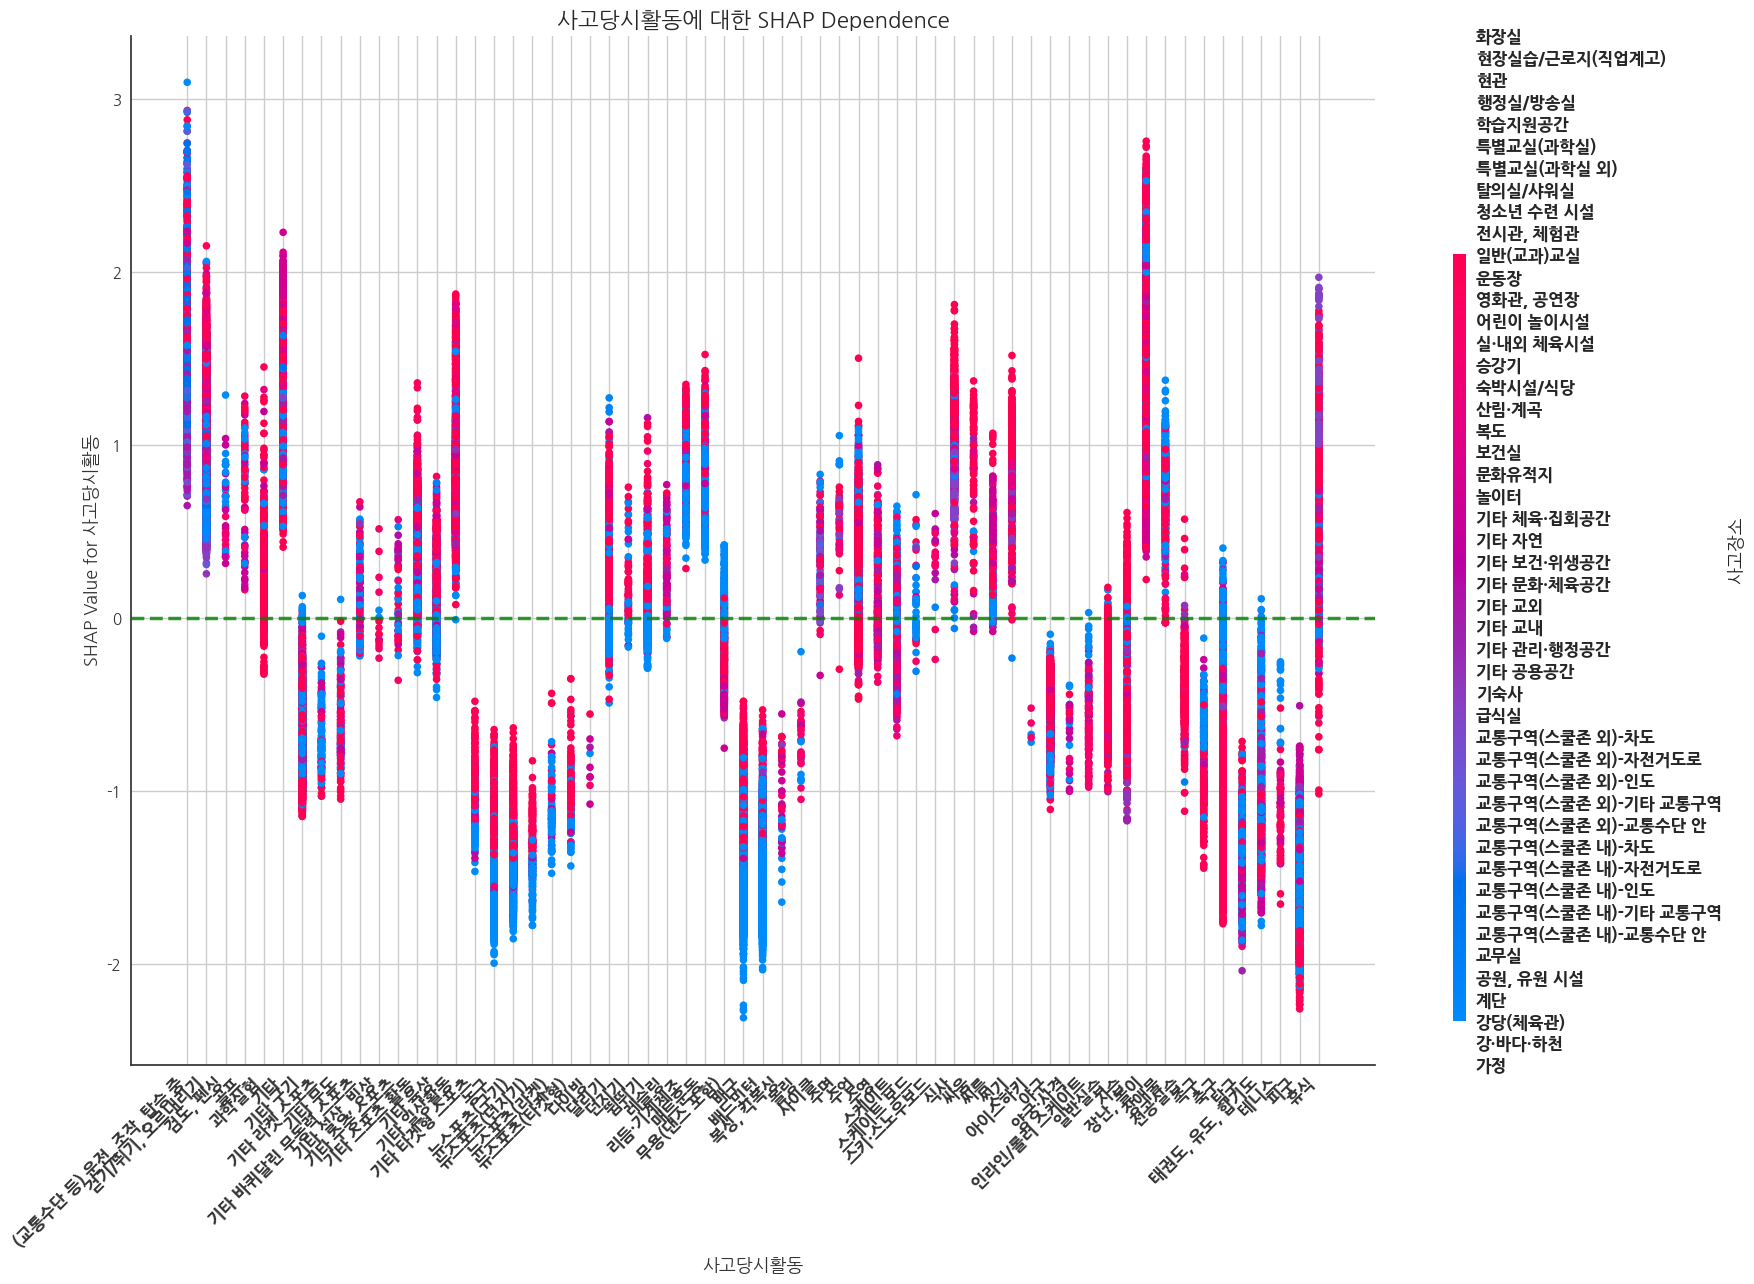

In [89]:
shap_dependence_plot_large(
    col='사고당시활동',
    shap_values=shap_values,
    X_train=X_train,
    le_dict=le_dict,
    interaction_col='사고장소',
    figsize=(18, 13),
    dot_size = 30
)


### 해석

앞서 설명한 해석 방법에 따르면

---
1) **초중고**는 주로 **체육/구기활동(축구,배드민턴,농구 등)** 을 하며 사고가 많이 발생함
2) 구기활동 특성에 맞게 주로 사고는 **야외(체육관, 공원, 차도 등)** 에서 발생함
----
3) 그러나 **유치원/특수학교**는 초중고와 달리 **기타(일상, 씻기, 장난 등) 활동**에서 사고가 많이 발생함
4) 이에 따라 사고 장소 역시 **실내(화장실, 현관, 교실, 등)에서 많이 발생함**
---

## 2. 사고시간과 사고장소

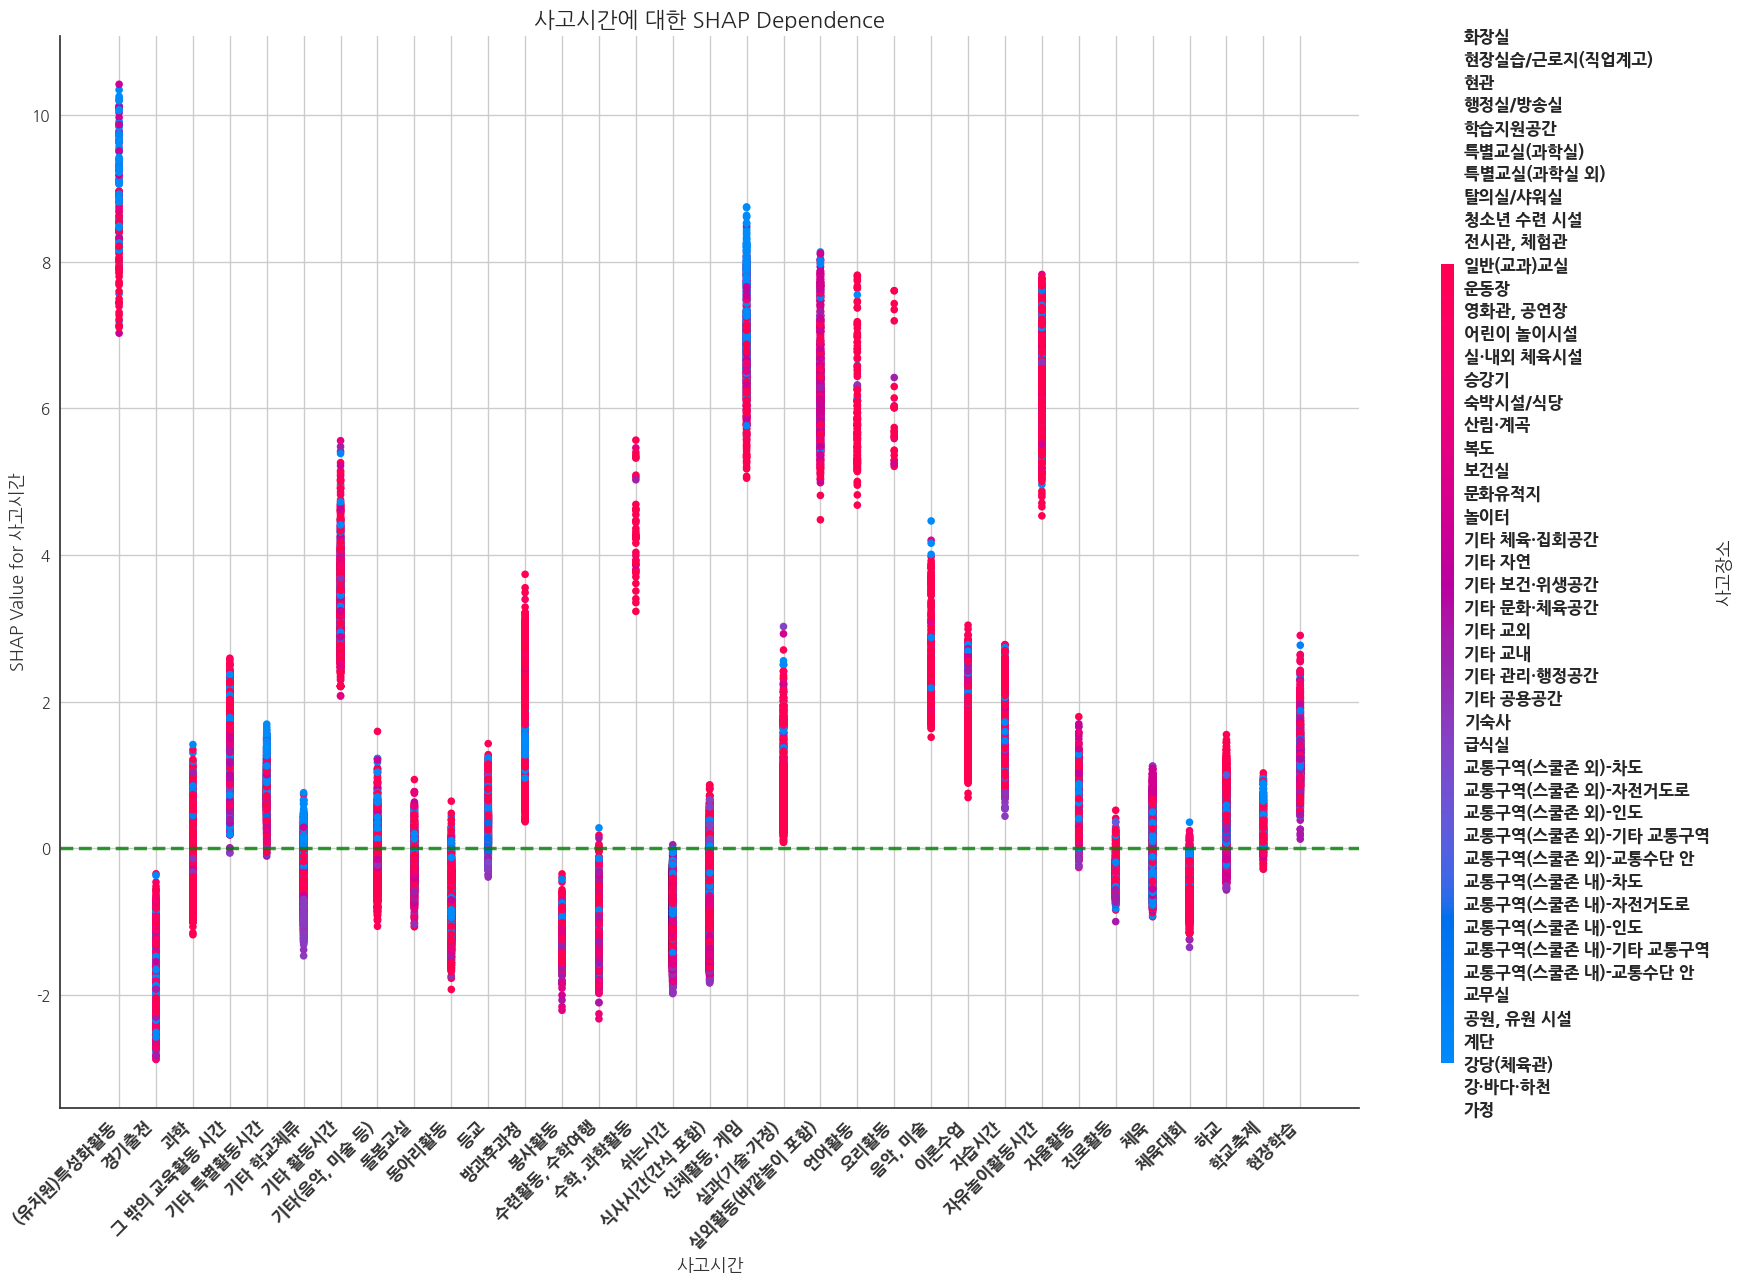

In [90]:
shap_dependence_plot_large(
    col='사고시간',
    shap_values=shap_values,
    X_train=X_train,
    le_dict=le_dict,
    interaction_col='사고장소',
    figsize=(18, 13),
    dot_size = 30
)


### 해석

앞서 설명한 해석 방법에 따르면

---
1) **초중고**의 사고 시간은 다분포가 아닌 특정 변수(특정 시간)들에 몰려있음.
2) 주로 수련활동, 봉사활동, 경기출전 등으로 유치원/특수학교 학생들이 하기 힘든 활동들임.
3) 혹은 식사시간, 쉬는시간 등 선생님들이 터치하기 어려운 시간대에 발생함.
----
3) **유치원/특수학교**의 경우 (유치원)특성화활동을 제외하고(유치원에서만 하기 때문에) 신체활동, 게임, 자율 활동, 실외활동, 언어활동, 요리활동, 기타활동 시간 등 다양하게 분포되어 있다.
4) 교육활동시간, 돌봄교실, 언어활동, 음악미술, 이론수업 등 정적인 시간보다는 위에서 말한 동적인 시간대에 더 유아/특수학교에서 발생한 사고라고 판단할 가능성이 높다.
---

# 최종 정리와 예방안 시시